# Librerías usadas

Instalar librerías
Utilidades información del sistema
Utilidades tiempo preprocesamiento

In [ ]:
%pip install kagglehub
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install torch
%pip install psutil
%pip install py-cpuinfo
%pip install loky

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Inhabilitar uso de threads en numpy

Inhabilitar cuando se uso procesos físicos para evitar competencia de recursos

Ejecutar antes de import numpy

**Si se ejecuto con threads y se quiere ejecutar con cpu física primero se debe reiniciar el kernel y ejecutar la celda, igualmente si se ejecuto la celda y quiere activar de nuevo los threads para numpy**

In [3]:
import os

# ── Configuración de threads ──────────────────────────────
DISABLE_NUMPY_THREADS = True  # cambiar a False para usar todos los threads

if DISABLE_NUMPY_THREADS:
    os.environ["OMP_NUM_THREADS"]     = "1"
    os.environ["MKL_NUM_THREADS"]     = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Para preparar Windows antes de ejecutar:

# Cerrar: navegador, programas, etc.
# Task Manager → pestaña Details → click derecho en python.exe → Set Priority → High
# O desde código:
# p = psutil.Process()
# p.nice(psutil.HIGH_PRIORITY_CLASS)  # Windows only

In [27]:
from kagglehub import dataset_download
from typing import Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
import torch
import platform
import psutil
import cpuinfo
import time
from functools import wraps
import os
from loky import get_reusable_executor

In [5]:
def print_system_info():
    print("=== SYSTEM INFO ===")
    print("OS:", platform.system(), platform.release())
    print("Machine:", platform.machine())

    info = cpuinfo.get_cpu_info()
    print("CPU:", info["brand_raw"])
    print("Architecture:", info["arch"])
    print("Physical cores:", psutil.cpu_count(logical=False))
    print("Logical threads:", psutil.cpu_count(logical=True))

    ram = psutil.virtual_memory()
    print("RAM (GB):", round(ram.total / (1024**3), 2))
    print(f"Cuda available: {torch.cuda.is_available()}")
    print(f"cpu_count: {os.cpu_count()}")


    print(f"CUDA available: {torch.cuda.is_available()}")

    if torch.cuda.is_available():
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"VRAM Total (GB): {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f}")
        print(f"VRAM Allocated (GB): {torch.cuda.memory_allocated(0) / 1024**3:.2f}")
        print(f"VRAM Reserved (GB): {torch.cuda.memory_reserved(0) / 1024**3:.2f}")

    print("_" * 40)


def time_wrapper(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        elapsed = time.perf_counter() - start

        if elapsed < 1:
            formatted = f"{elapsed * 1000:.2f} ms"
        elif elapsed < 60:
            formatted = f"{elapsed:.2f} s"
        elif elapsed < 3600:
            mins, secs = divmod(elapsed, 60)
            formatted = f"{int(mins)}m {secs:.2f}s"
        else:
            hours, remainder = divmod(elapsed, 3600)
            mins, secs = divmod(remainder, 60)
            formatted = f"{int(hours)}h {int(mins)}m {secs:.2f}s"

        print(f"{func.__name__} took {formatted}")
        return result

    return wrapper



# Carga de datos

In [6]:
class MnistData:
    def __init__(self):
        self.dataset_path = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None

    def download_data(self) -> None:
        self.dataset_path = dataset_download("oddrationale/mnist-in-csv")

    def load_data(self, one_hot: bool = True) -> None:
        train_df = pd.read_csv(self.dataset_path + "/mnist_train.csv")
        test_df = pd.read_csv(self.dataset_path + "/mnist_test.csv")

        self.X_train = train_df.iloc[
            :, 1:
        ].values  # 60000 imágenes de 784 píxeles (28x28)
        self.y_train = train_df.iloc[:, 0].values  # 60000 etiquetas (0-9)
        self.X_test = test_df.iloc[:, 1:].values
        self.y_test = test_df.iloc[:, 0].values

        self.X_train = self.X_train.astype("float32") / 255.0
        self.X_test = self.X_test.astype("float32") / 255.0

        if one_hot:
            self.y_train = self.one_hot_encode(self.y_train)
            self.y_test = self.one_hot_encode(self.y_test)

    def get_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        return self.X_train, self.y_train, self.X_test, self.y_test

    def plot_random_samples(self, n_samples=10) -> None:
        indices = np.random.choice(len(self.X_train), n_samples, replace=False)
        samples = self.X_train[indices]
        labels = self.y_train[indices]

        # labels a entero si es one-hot
        if labels.ndim == 2:
            labels = np.argmax(labels, axis=1)

        plt.figure(figsize=(10, 1))

        for i in range(n_samples):
            plt.subplot(1, n_samples, i + 1)
            plt.imshow(samples[i].reshape(28, 28), cmap="gray")
            plt.title(f"Label: {labels[i]}")
            plt.axis("off")

        plt.show()

    def train_val_split(self, val_ratio: float = 0.1, seed: int = 42):
        """
        Particiona X_train/y_train en train+val.
        val_ratio: fracción para validación, ej. 0.1 → 6000 muestras
        """
        np.random.seed(seed)
        n = len(self.X_train)
        idx = np.random.permutation(n)
        split = int(n * val_ratio)
        val_idx, train_idx = idx[:split], idx[split:]
        return (
            self.X_train[train_idx],
            self.y_train[train_idx],
            self.X_train[val_idx],
            self.y_train[val_idx],
        )

    def one_hot_encode(self, y: np.ndarray, n_classes: int = 10) -> np.ndarray:
        """
        Convierte etiquetas enteras a vectores one-hot.

        y: array (N,) con valores en {0,...,9}
        retorna: (N, 10) donde cada fila es e_k
        """
        one_hot = np.zeros((len(y), n_classes), dtype="float32")
        one_hot[np.arange(len(y)), y] = 1.0
        return one_hot

    def get_batches(
        self, X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool = True
    ):
        """
        Generador de mini-batches.

        Para N muestras y tamaño B, produce ceil(N/B) batches.
        Si shuffle=True, permuta antes de particionar (esencial en SGD/mini-batch
        para no introducir sesgo por orden de clase).
        """
        n = len(X)
        idx = np.random.permutation(n) if shuffle else np.arange(n)
        for start in range(0, n, batch_size):
            batch_idx = idx[start : start + batch_size]
            yield X[batch_idx], y[batch_idx]


# Funciones de activación

In [7]:
class ActivationFunction(ABC):
    """
    Clase base abstracta para funciones de activación.

    Toda función de activación f: R -> R (o R^n -> R^n) debe implementar:
      - function(x)   : la función f(x)
      - derivative(x) : la derivada f'(x) respecto a x

    El método __call__ delega a function(x) para uso natural: relu(x)
    """

    def __init__(self):
        super().__init__()

    def function(self, x):
        raise NotImplementedError("Subclasses must implement this method")

    def derivative(self, x):
        raise NotImplementedError("Subclasses must implement this method")

    def plot(self, x_range=(-10, 10), num_points=1000):
        """Grafica f(x) y f'(x) lado a lado."""
        x = np.linspace(x_range[0], x_range[1], num_points)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(x, self.function(x), color="steelblue")
        axes[0].set_title(f"{self.__class__.__name__}  —  f(x)")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("f(x)")
        axes[0].axhline(0, color="k", linewidth=0.8)
        axes[0].axvline(0, color="k", linewidth=0.8)
        axes[0].grid(alpha=0.3)

        axes[1].plot(x, self.derivative(x), color="tomato")
        axes[1].set_title(f"{self.__class__.__name__}  —  f'(x)")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("f'(x)")
        axes[1].axhline(0, color="k", linewidth=0.8)
        axes[1].axvline(0, color="k", linewidth=0.8)
        axes[1].grid(alpha=0.3)

        plt.suptitle(self.__class__.__name__, fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def __call__(self, x):
        return self.function(x)


# ──────────────────────────────────────────────
# ReLU  —  Rectified Linear Unit
# ──────────────────────────────────────────────
#
#          ⎧  0   si x ≤ 0
#  f(x) =  ⎨
#          ⎩  x   si x > 0
#
#  = max(0, x)
#
#          ⎧  0   si x < 0
#  f'(x) = ⎨  ?   si x = 0   (subgradiente, usamos 0)
#          ⎩  1   si x > 0
#
#  Ventaja : gradiente constante → no hay vanishing gradient en zona activa
#  Problema: "dying ReLU" — neuronas que quedan siempre en x<0 dejan de aprender
#
class ReLU(ActivationFunction):
    def function(self, x):
        return np.maximum(0, x)

    def derivative(self, x):
        return (x > 0).astype(float)



# ──────────────────────────────────────────────
# Softmax
# ──────────────────────────────────────────────
#
#           e^(x_i - max(x))
#  f(x)_i = ─────────────────      i = 0,...,K-1
#            Σ_j e^(x_j - max(x))
#
#  El shift por max(x) es estabilidad numérica (evita overflow), no cambia el resultado:
#    e^(x_i - c) / Σ e^(x_j - c) = e^x_i / Σ e^x_j
#
#  Salida: distribución de probabilidad — Σ_i f(x)_i = 1, f(x)_i ∈ (0,1)
#
#  Jacobiana (derivada completa es una matriz, no un vector):
#
#    ∂f_i/∂x_j = f_i · (δ_ij - f_j)
#
#    En forma matricial para un vector s = softmax(x):
#      J = diag(s) - s·sᵀ     (matriz K×K)
#
#  ⚠️  ADVERTENCIA IMPORTANTE:
#  En la práctica, Softmax se usa SIEMPRE con Cross-Entropy como loss.
#  El gradiente combinado ∂L/∂x = ŷ - y es muy simple (ver CostFunction).
#  La Jacobiana completa RARAMENTE se necesita sola.
#
#  El método derivative() aquí devuelve el jacobiano por fila (útil para
#  visualización o casos edge), PERO en el backward pass de la red
#  usar el gradiente combinado Softmax + CrossEntropy directamente.
#
class Softmax(ActivationFunction):
    def function(self, x):
        # x shape: (N, K) — N muestras, K clases
        # shift por max en cada fila para estabilidad numérica
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

    def derivative(self, x):
        """
        Jacobiana de softmax para cada muestra.

        Para un vector s = softmax(x) de dim K:
          J_ij = s_i * (delta_ij - s_j)

        Retorna shape (N, K, K) — un jacobiano K×K por cada muestra.
        Usar solo cuando se necesite la derivada aislada de softmax.
        En backprop con cross-entropy usar gradiente combinado: (ŷ - y)
        """
        s = self.function(x)  # (N, K)
        # diag(s) por fila - s·sᵀ por fila
        return np.einsum("ij,jk->ijk", s, np.eye(s.shape[-1])) - np.einsum(
            "ij,ik->ijk", s, s
        )

    def gradient_with_cross_entropy(
        self, y_pred: np.ndarray, y_true: np.ndarray
    ) -> np.ndarray:
        """
        Gradiente combinado Softmax + Cross-Entropy (lo que realmente usas en backprop).

        ∂L/∂z = ŷ - y    donde z es la entrada pre-activación (logits)

        Derivación:
          L = -Σ_i y_i · log(ŷ_i)       (cross-entropy)
          ŷ = softmax(z)

          ∂L/∂z_i = ŷ_i - y_i           (resultado elegante del par softmax+CE)

        y_pred: (N, K) probabilidades predichas
        y_true: (N, K) one-hot
        retorna: (N, K)
        """
        return (y_pred - y_true) / y_pred.shape[0]



# Funciones de costo

In [8]:

class CostFunction(ABC):
    """
    Clase base para funciones de costo L(y_true, y_pred).

    Convención de shapes:
      y_true : (N, K)  one-hot  — o (N,) enteros según la subclase
      y_pred : (N, K)  probabilidades o logits según la subclase
      N = batch size, K = número de clases

    derivative() devuelve ∂L/∂y_pred, shape (N, K)
    El promedio sobre N es responsabilidad de cada subclase (documentado).
    """

    def __init__(self):
        super().__init__()

    def function(self, y_true, y_pred):
        raise NotImplementedError

    def derivative(self, y_true, y_pred):
        raise NotImplementedError

    def __call__(self, y_true, y_pred):
        return self.function(y_true, y_pred)

    def _parse_y_true(self, y_true: np.ndarray, K: int) -> np.ndarray:
        """
        Normaliza y_true a one-hot (N, K) independientemente del formato de entrada.

        Acepta:
        - (N,)   enteros en {0,...,K-1}
        - (N,1)  enteros
        - (N,K)  one-hot o probabilidades suaves (soft labels)
        """
        if y_true.ndim == 1 or (y_true.ndim == 2 and y_true.shape[1] == 1):
            idx = y_true.flatten().astype(int)
            one_hot = np.zeros((len(idx), K), dtype=float)
            one_hot[np.arange(len(idx)), idx] = 1.0
            return one_hot
        elif y_true.ndim == 2 and y_true.shape[1] == K:
            return y_true  # ya está en el formato correcto
        else:
            raise ValueError(
                f"y_true shape {y_true.shape} incompatible con K={K} clases."
            )

    """
    Cross-Entropy acoplada con Softmax.

    y_true : (N, K) one-hot         ← cambio respecto a versión anterior
    y_pred : (N, K) logits (z)      ← NO probabilidades, mejora estabilidad
    """

    def _softmax(self, z):
        # Método interno — no exponer como softmax independiente.
        # La clase de activación Softmax existe para eso.
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def function(self, y_true, y_pred):
        """
        L = -(1/N) Σ_n Σ_k  y_nk · log(ŷ_nk + ε)

        ε = 1e-12 evita log(0) si alguna probabilidad colapsa a 0.
        """
        K = y_pred.shape[1]
        y_true = self._parse_y_true(y_true, K)
        y_hat = self._softmax(y_pred)
        eps = 1e-12
        return -np.mean(np.sum(y_true * np.log(y_hat + eps), axis=1))

    def derivative(self, y_true, y_pred):
        """
        ∂L/∂z = (1/N)(ŷ - y)

        Gradiente respecto a logits z — listo para backprop directamente.
        """
        K = y_pred.shape[1]
        y_true = self._parse_y_true(y_true, K)
        y_hat = self._softmax(y_pred)
        return (y_hat - y_true) / y_pred.shape[0]


# ──────────────────────────────────────────────
# Mean Squared Error
# ──────────────────────────────────────────────
#
#  L = (1/N) Σ_n ||y_n - ŷ_n||²
#    = (1/N) Σ_n Σ_k (y_nk - ŷ_nk)²
#
#  ∂L/∂ŷ = (2/N)(ŷ - y)
#
#  Para clasificación con one-hot, MSE penaliza todas las clases por igual
#  lo que no es ideal — CrossEntropy es mejor para clasificación.
#  MSE sí tiene sentido en la capa de salida de un autoencoder o regresión.
#
class MeanSquaredError(CostFunction):
    """
    y_true : (N, K) one-hot o valores continuos
    y_pred : (N, K) salida de la red (post-activación)
    """

    def function(self, y_true, y_pred):
        return np.mean(np.sum((y_true - y_pred) ** 2, axis=1))

    def derivative(self, y_true, y_pred):
        """
        ∂L/∂ŷ = (2/N)(ŷ - y)

        Factor 2 se suele absorber en el learning rate,
        algunos frameworks usan (1/N)(ŷ - y) omitiendo el 2.
        """
        return 2 * (y_pred - y_true) / y_true.shape[0]



# Inicializadores

In [9]:

class WeightInitializer(ABC):
    """
    Clase base para inicialización de pesos.

    La inicialización importa porque determina:
      - Si los gradientes explotan o desaparecen en las primeras iteraciones
      - Qué tan rápido converge el entrenamiento
      - Si las activaciones se saturan desde el inicio

    Convención: retorna W de shape (input_size, output_size)
    Los bias se inicializan en cero por separado en la capa.
    """

    def __init__(self):
        super().__init__()

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        raise NotImplementedError

    def __call__(self, input_size: int, output_size: int) -> np.ndarray:
        return self.initialize(input_size, output_size)


# ──────────────────────────────────────────────
# Random Normal
# ──────────────────────────────────────────────
#
#  W ~ N(0, 1)
#
#  El problema: sin escalar, la varianza de la salida crece con input_size.
#  Si input_size=784 (MNIST), las activaciones explotan inmediatamente.
#
#  ❌ No usar en producción — sirve para demostrar por qué importa
#     la inicialización correcta (experimento didáctico).
#
class RandomNormal(WeightInitializer):
    """
    W ~ N(0, 1)  — sin escalar.
    Solo útil para ilustrar el problema de inicialización naive.
    """
    def __init__(self, std: float = 1.0):
        super().__init__()
        self.std = std

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        return np.random.randn(input_size, output_size) * self.std



# Capas

In [10]:

class Layer(ABC):
    """
    Clase base para capas de una red neuronal.

    Una capa transforma una entrada X de shape (N, n_in)
    a una salida de shape (N, n_out) donde N = batch size.

    Todo Layer debe implementar:
      forward(X)      : paso hacia adelante  X -> ŷ
      backward(delta) : paso hacia atrás     ∂L/∂X <- ∂L/∂ŷ

    El backward recibe el gradiente de la loss respecto a la
    SALIDA de esta capa, y devuelve el gradiente respecto a
    la ENTRADA (para propagarlo a la capa anterior).
    Los gradientes de W y b se almacenan en self.d_weights, self.d_bias.
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        activation: ActivationFunction,
        weight_initializer: WeightInitializer,
    ):
        # weight_initializer debe ser una INSTANCIA, no la clase
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.activation = activation

        self.initializer = weight_initializer
        self.weights = weight_initializer.initialize(input_size, output_size)
        self.bias = np.zeros((1, output_size))

        # Gradientes — se llenan en backward, se leen en el optimizer
        self.d_weights = None
        self.d_bias = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def backward(self, delta: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def __call__(self, X: np.ndarray) -> np.ndarray:
        return self.forward(X)

    def __repr__(self):
        return (
            f"{self.__class__.__name__}("
            f"in={self.input_size}, "
            f"out={self.output_size}, "
            f"activation={self.activation.__class__.__name__})"
        )


# ──────────────────────────────────────────────
# Dense  —  capa completamente conectada
# ──────────────────────────────────────────────
#
#  FORWARD
#  ───────
#  Dado un batch X de shape (N, n_in):
#
#    Z = X · W + b          shape: (N, n_out)
#    A = f(Z)               shape: (N, n_out)
#
#  donde W shape (n_in, n_out), b shape (1, n_out) — broadcast sobre N
#  f es la función de activación
#
#  BACKWARD
#  ────────
#  Recibe delta = ∂L/∂A de shape (N, n_out)
#  Necesita calcular:
#
#  1) Gradiente respecto a Z (pre-activación):
#
#       δZ = delta ⊙ f'(Z)       shape: (N, n_out)
#
#     ⊙ = producto elemento a elemento (Hadamard)
#
#  2) Gradiente respecto a W:
#
#       ∂L/∂W = Xᵀ · δZ          shape: (n_in, n_out)
#
#  3) Gradiente respecto a b:
#
#       ∂L/∂b = Σ_n δZ_n          shape: (1, n_out)
#             = sum(δZ, axis=0)
#
#  4) Gradiente respecto a X (para propagar a capa anterior):
#
#       ∂L/∂X = δZ · Wᵀ           shape: (N, n_in)
#
#  ⚠️  CASO ESPECIAL — Softmax en capa de salida:
#  Si la activación es Softmax y se usa con CrossEntropy,
#  el delta que llega ya ES (ŷ - y)/N (gradiente combinado).
#  En ese caso f'(Z) NO se aplica aquí — CrossEntropy.derivative()
#  ya lo absorbió. La capa detecta esto automáticamente.
#
class Dense(Layer):
    """
    Capa densa: A = f(X·W + b)

    Parámetros aprendibles: W (n_in, n_out), b (1, n_out)
    """

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Guarda X y Z para usar en backward.

        X : (N, n_in)
        Z : (N, n_out)  — pre-activación, necesaria para f'(Z)
        A : (N, n_out)  — salida post-activación
        """
        self.X = X
        self.Z = np.dot(X, self.weights) + self.bias
        return self.activation(self.Z)

    def backward(self, delta: np.ndarray) -> np.ndarray:
        """
        delta : ∂L/∂A  shape (N, n_out)

        Si la activación es Softmax, delta ya viene como (ŷ - y)/N
        desde CrossEntropy.derivative() — no aplicar f'(Z) de nuevo.
        """
        if isinstance(self.activation, Softmax):
            # delta = (ŷ - y)/N, ya es ∂L/∂Z directamente
            dZ = delta
        else:
            # Regla general: δZ = delta ⊙ f'(Z)
            dZ = delta * self.activation.derivative(self.Z)

        self.d_weights = np.dot(self.X.T, dZ)  # (n_in, n_out)
        self.d_bias = np.sum(dZ, axis=0, keepdims=True)  # (1, n_out)

        return np.dot(dZ, self.weights.T)  # (N, n_in)

    def __repr__(self):
        return (
            f"Dense(in={self.input_size}, "
            f"out={self.output_size}, "
            f"activation={self.activation.__class__.__name__})"
        )



# Optimizadores

In [11]:
class Optimizer(ABC):
    """
    Clase base para optimizadores.

    Un optimizador actualiza los parámetros W y b de cada capa
    usando los gradientes ∂L/∂W y ∂L/∂b calculados en backward.

    El optimizador NO conoce la loss ni calcula gradientes —
    solo recibe gradientes ya calculados y decide cómo aplicarlos.

    step(layers) : realiza una actualización de parámetros
    reset()      : reinicia estado interno (momentum, cache, etc.)
    """

    def __init__(self, learning_rate: float = 0.01):
        super().__init__()
        if learning_rate <= 0:
            raise ValueError(f"learning_rate debe ser > 0. Recibido: {learning_rate}")
        self.lr = learning_rate

    def step(self, layers: list) -> None:
        raise NotImplementedError

    def reset(self) -> None:
        pass

    def _has_params(self, layer) -> bool:
        """Verifica que la capa tiene parámetros aprendibles (no Dropout, etc.)"""
        return layer.weights is not None and layer.d_weights is not None


# ──────────────────────────────────────────────
# SGD  —  Stochastic Gradient Descent
# ──────────────────────────────────────────────
#
#  La regla de actualización más simple:
#
#    W = W - η · ∂L/∂W
#    b = b - η · ∂L/∂b
#
#  η = learning rate — cuánto nos movemos en dirección del gradiente negativo.
#
#  Intuición geométrica:
#    El gradiente ∂L/∂W apunta hacia la dirección de mayor AUMENTO de L.
#    Restarlo mueve W hacia donde L DECRECE — descenso del gradiente.
#
#  Problemas:
#    - η grande  → pasos grandes → puede diverger u oscilar
#    - η pequeño → converge pero muy lento
#    - En valles elongados oscila en la dirección de mayor curvatura
#      y avanza lento en la dirección de menor curvatura
#
#  A pesar de sus limitaciones, SGD bien tuneado compite con Adam en MNIST.
#
class SGD(Optimizer):
    """
    W ← W - η · ∂L/∂W
    b ← b - η · ∂L/∂b
    """

    def __init__(self, learning_rate: float = 0.01):
        super().__init__(learning_rate)

    def step(self, layers: list) -> None:
        for layer in layers:
            if not self._has_params(layer):
                continue
            layer.weights -= self.lr * layer.d_weights
            layer.bias -= self.lr * layer.d_bias



# Red

In [12]:

# ──────────────────────────────────────────────
# Network
# ──────────────────────────────────────────────
#
#  Representa el grafo de cómputo de la red neuronal.
#  Conecta capas secuencialmente y gestiona el flujo
#  de datos en ambas direcciones.
#
#  FORWARD PASS
#  ────────────
#  Dada entrada X de shape (N, n_in), propaga por cada capa:
#
#    A_0 = X
#    A_l = f_l(A_{l-1})    l = 1, ..., L
#
#  La salida A_L es la predicción de la red.
#
#  BACKWARD PASS
#  ─────────────
#  Recibe el gradiente inicial δ = ∂L/∂A_L de la loss,
#  propaga en orden inverso:
#
#    δ_{l-1} = layer_l.backward(δ_l)    l = L, ..., 1
#
#  Cada capa acumula d_weights y d_bias internamente.
#  El optimizer los lee después con optimizer.step(layers).
#
#  TRAINING vs INFERENCE
#  ──────────────────────
#  Dropout se comporta distinto en cada modo.
#  Network gestiona el flag training en todas las capas
#  antes de cada forward — el usuario no tiene que hacerlo.
#
class Network():
    """
    Grafo de cómputo secuencial.

    No conoce la loss, el optimizer ni los datos —
    solo sabe propagar hacia adelante y hacia atrás.

    Uso básico:
        net = Network()
        net.add(Dense(784, 128, Tanh(), XavierUniform()))
        net.add(Dropout(0.3))
        net.add(Dense(128, 10, Softmax(), XavierUniform()))

        y_pred = net.forward(X)          # inference por default
        y_pred = net.forward(X, training=True)  # training
        grad   = net.backward(delta)
    """

    def __init__(self):
        super().__init__()
        self.layers = []

    # ──────────────────────────────────────────
    # Construcción
    # ──────────────────────────────────────────

    def add(self, layer) -> "Network":
        """
        Agrega una capa al final de la red.
        Retorna self para permitir encadenamiento:

            net.add(Dense(...)).add(Dropout(...)).add(Dense(...))
        """
        self.layers.append(layer)
        return self

    def __len__(self) -> int:
        return len(self.layers)

    # ──────────────────────────────────────────
    # Forward
    # ──────────────────────────────────────────

    def forward(self, X: np.ndarray, training: bool = False) -> np.ndarray:
        """
        Propaga X por todas las capas en orden.

        training : True  durante entrenamiento (activa Dropout, etc.)
                   False durante inference (default)

        A_0 = X
        A_l = layer_l(A_{l-1})    l = 1,...,L

        Retorna A_L de shape (N, n_out)
        """
        self._set_training(training)

        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def __call__(self, X: np.ndarray, training: bool = False) -> np.ndarray:
        return self.forward(X, training)

    # ──────────────────────────────────────────
    # Backward
    # ──────────────────────────────────────────

    def backward(self, delta: np.ndarray) -> np.ndarray:
        """
        Propaga el gradiente en orden inverso.

        delta : ∂L/∂A_L — gradiente de la loss respecto
                a la salida de la última capa. Shape (N, n_out).

        Cada capa acumula d_weights y d_bias.
        Retorna el gradiente respecto a la entrada X (raramente
        necesario fuera de redes más complejas).

        ⚠️  Llamar siempre DESPUÉS de forward(training=True).
            backward sin forward previo usa cachés desactualizados.
        """
        for layer in reversed(self.layers):
            delta = layer.backward(delta)
        return delta


    def reset_weights(self) -> None:
        """
        Reinicializa W y b de todas las capas entrenables.
        Llamar entre experimentos para comparación justa.
        """
        for layer in self.trainable_layers():
            layer.weights = layer.initializer.initialize(
                layer.input_size, layer.output_size
            )
            layer.bias = np.zeros((1, layer.output_size))

    # ──────────────────────────────────────────
    # Parámetros
    # ──────────────────────────────────────────

    def trainable_layers(self) -> list:
        """
        Retorna solo las capas con parámetros aprendibles (W, b).
        El optimizer llama esto para saber qué actualizar.
        """
        return [l for l in self.layers if l.weights is not None]

    def parameter_count(self) -> int:
        """
        Cuenta el total de parámetros aprendibles de la red.

        Para una capa Dense(n_in, n_out):
          params = n_in * n_out  (W)  +  n_out  (b)
        """
        total = 0
        for layer in self.trainable_layers():
            total += layer.weights.size + layer.bias.size
        return total

    # ──────────────────────────────────────────
    # Persistencia  —  guardar y cargar pesos
    # ──────────────────────────────────────────

    def save_weights(self, path: str) -> None:
        """
        Guarda W y b de cada capa entrenable en un archivo .npz.

        Formato: weights_0, bias_0, weights_1, bias_1, ...
        El índice corresponde a la posición en trainable_layers().
        """
        data = {}
        for i, layer in enumerate(self.trainable_layers()):
            data[f"weights_{i}"] = layer.weights
            data[f"bias_{i}"] = layer.bias
        np.savez(path, **data)

    def load_weights(self, path: str) -> None:
        """
        Carga pesos desde un .npz guardado con save_weights().

        ⚠️  La arquitectura debe ser idéntica a la que generó el archivo.
        """
        data = np.load(path)
        layers = self.trainable_layers()

        for i, layer in enumerate(layers):
            key_w = f"weights_{i}"
            key_b = f"bias_{i}"

            if key_w not in data or key_b not in data:
                raise ValueError(
                    f"Archivo no contiene pesos para capa {i}. "
                    f"¿La arquitectura coincide con el archivo?"
                )

            if data[key_w].shape != layer.weights.shape:
                raise ValueError(
                    f"Shape mismatch en capa {i}: "
                    f"archivo={data[key_w].shape}, "
                    f"red={layer.weights.shape}"
                )

            layer.weights = data[key_w]
            layer.bias = data[key_b]

    # ──────────────────────────────────────────
    # Utilidades
    # ──────────────────────────────────────────

    def _set_training(self, training: bool) -> None:
        """
        Propaga el flag training a todas las capas que lo usen (Dropout).
        Se llama automáticamente en forward().
        """
        for layer in self.layers:
            if hasattr(layer, "training"):
                layer.training = training

    def summary(self) -> None:
        """
        Imprime la arquitectura de la red con shapes y parámetros.

        Ejemplo:
        ┌─────────────────────────────────────────────────┐
        │                  Network Summary                │
        ├──────────────────────┬───────────┬──────────────┤
        │ Layer                │ Shape     │ Params       │
        ├──────────────────────┼───────────┼──────────────┤
        │ Dense (Tanh)         │ 784→128   │ 100,480      │
        │ Dropout (p=0.3)      │    —      │       0      │
        │ Dense (Softmax)      │ 128→10    │   1,290      │
        ├──────────────────────┼───────────┼──────────────┤
        │ Total params         │           │ 101,770      │
        └─────────────────────────────────────────────────┘
        """
        sep = "─" * 52
        total = 0

        print(f"┌{sep}┐")
        print(f"│{'Network Summary':^52}│")
        print(f"├{'─'*22}┬{'─'*11}┬{'─'*16}┤")
        print(f"│{'Layer':<22}│{'Shape':^11}│{'Params':>14}  │")
        print(f"├{'─'*22}┼{'─'*11}┼{'─'*16}┤")

        for layer in self.layers:
            if layer.weights is not None:
                name = f"{layer.__class__.__name__} ({layer.activation.__class__.__name__})"
                shape = f"{layer.input_size}→{layer.output_size}"
                params = layer.weights.size + layer.bias.size
                total += params
                print(f"│{name:<22}│{shape:^11}│{params:>14,}  │")
            else:
                name = repr(layer)
                print(f"│{name:<22}│{'—':^11}│{'0':>14}  │")

        print(f"├{'─'*22}┴{'─'*11}┴{'─'*16}┤")
        print(f"│{'Total params':<22}  {total:>26,}  │")
        print(f"└{sep}┘")

    def __repr__(self) -> str:
        lines = [f"Network({len(self.layers)} layers)"]
        for i, layer in enumerate(self.layers):
            lines.append(f"  [{i}] {repr(layer)}")
        return "\n".join(lines)



# Historial

In [13]:
class History:
    """
    Registra métricas por epoch durante el entrenamiento.

    Atributos:
        train_loss     : list[float]  — loss promedio por epoch (train)
        train_accuracy : list[float]  — accuracy por epoch (train)
        train_grad_norm : norma de Frobenius promedio del gradiente por epoch
                          ||∂L/∂W||_F = sqrt(Σ_ij (∂L/∂W_ij)²)
                          Útil para detectar:
                            - grad_norm → 0   vanishing gradient
                            - grad_norm → ∞   exploding gradient
                            - grad_norm estable → entrenamiento saludable
        val_loss       : list[float]  — loss promedio por epoch (val)
        val_accuracy   : list[float]  — accuracy por epoch (val)
        epochs         : list[int]    — índices de epoch registrados
    """

    def __init__(self):
        self.train_loss = []
        self.train_accuracy = []
        self.train_grad_norm = []
        self.val_loss = []
        self.val_accuracy = []
        self.epochs = []

    def record(
        self,
        epoch: int,
        train_loss: float,
        train_acc: float,
        grad_norm: float = None,
        val_loss: float = None,
        val_acc: float = None,
    ) -> None:
        self.epochs.append(epoch)
        self.train_loss.append(train_loss)
        self.train_accuracy.append(train_acc)
        self.train_grad_norm.append(grad_norm if grad_norm is not None else 0.0)

        if val_loss is not None:
            self.val_loss.append(val_loss)
            self.val_accuracy.append(val_acc)

    def plot(self, show_grad_norm: bool = True) -> None:
        """
        Grafica las métricas registradas durante el entrenamiento.

        show_grad_norm=True agrega un tercer panel con la norma del gradiente.
        """
        has_val = len(self.val_loss) > 0
        has_grad = show_grad_norm and any(g > 0 for g in self.train_grad_norm)
        n_panels = 3 if has_grad else 2

        fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))

        # ── Loss ──
        axes[0].plot(self.epochs, self.train_loss, label="Train", color="steelblue")
        if has_val:
            axes[0].plot(
                self.epochs, self.val_loss, label="Val", color="tomato", linestyle="--"
            )
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # ── Accuracy ──
        axes[1].plot(self.epochs, self.train_accuracy, label="Train", color="steelblue")
        if has_val:
            axes[1].plot(
                self.epochs,
                self.val_accuracy,
                label="Val",
                color="tomato",
                linestyle="--",
            )
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_ylim(0, 1)
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        # ── Grad norm ──
        if has_grad:
            axes[2].plot(
                self.epochs, self.train_grad_norm, color="seagreen", label="||∂L/∂W||_F"
            )
            axes[2].set_title("Gradient Norm")
            axes[2].set_xlabel("Epoch")
            axes[2].set_ylabel("||∂L/∂W||_F")
            axes[2].legend()
            axes[2].grid(alpha=0.3)

        plt.suptitle("Training History", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def plot_comparison(
        self,
        other: "History",
        label_self: str = "Model A",
        label_other: str = "Model B",
    ) -> None:
        """
        Compara dos historiales — útil para comparar modos de GD,
        optimizadores, o arquitecturas distintas.

        Ejemplo:
            history_adam.plot_comparison(history_sgd,
                                         label_self="Adam",
                                         label_other="SGD")
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        pairs = [
            (self.train_loss, other.train_loss, "Loss", "Loss"),
            (self.train_accuracy, other.train_accuracy, "Accuracy", "Accuracy"),
            (
                self.train_grad_norm,
                other.train_grad_norm,
                "Gradient Norm",
                "||∂L/∂W||_F",
            ),
        ]
        colors = [
            ("steelblue", "tomato"),
            ("steelblue", "tomato"),
            ("seagreen", "darkorange"),
        ]

        for ax, (a, b, title, ylabel), (ca, cb) in zip(axes, pairs, colors):
            ax.plot(self.epochs, a, label=label_self, color=ca)
            ax.plot(other.epochs, b, label=label_other, color=cb, linestyle="--")
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel)
            ax.legend()
            ax.grid(alpha=0.3)

        plt.suptitle("Comparison", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def summary_table(self) -> None:
        """
        Imprime tabla resumen con best/last por métrica.

        ┌─────────────────────┬────────────┬────────────┐
        │ Métrica             │    Best    │    Last    │
        ├─────────────────────┼────────────┼────────────┤
        │ train_loss          │   0.0812   │   0.0934   │
        ...
        """
        metrics = [
            ("train_loss", self.train_loss, min),
            ("train_accuracy", self.train_accuracy, max),
            ("train_grad_norm", self.train_grad_norm, min),
        ]

        if self.val_loss:
            metrics += [
                ("val_loss", self.val_loss, min),
                ("val_accuracy", self.val_accuracy, max),
            ]

        sep = "─" * 45
        print(f"┌{sep}┐")
        print(f"│{'Training Summary':^45}│")
        print(f"├{'─'*21}┬{'─'*11}┬{'─'*11}┤")
        print(f"│{'Métrica':<21}│{'Best':^11}│{'Last':^11}│")
        print(f"├{'─'*21}┼{'─'*11}┼{'─'*11}┤")

        for name, values, best_fn in metrics:
            if values:
                best = best_fn(values)
                last = values[-1]
                print(f"│{name:<21}│{best:^11.4f}│{last:^11.4f}│")

        print(f"└{'─'*21}┴{'─'*11}┴{'─'*11}┘")

    def __repr__(self) -> str:
        if not self.epochs:
            return "History(vacío)"

        s = (
            f"History(epochs={self.epochs[-1]}, "
            f"train_loss={self.train_loss[-1]:.4f}, "
            f"train_acc={self.train_accuracy[-1]:.4f}, "
            f"grad_norm={self.train_grad_norm[-1]:.4f}"
        )

        if self.val_loss:
            s += (
                f", val_loss={self.val_loss[-1]:.4f}, "
                f"val_acc={self.val_accuracy[-1]:.4f}"
            )
        return s + ")"


# Modelo

In [28]:
from typing import Union
from concurrent.futures import ProcessPoolExecutor, as_completed

class TrainingStrategy(ABC):
    """
    Contrato base para todas las estrategias de entrenamiento.

    Una estrategia implementa UN paso por época y devuelve
    las métricas (loss, accuracy, grad_norm).

    Recibe acceso al modelo para poder llamar:
        model.network, model.cost, model.optimizer
        model._accuracy(), model._compute_grad_norm()
    """
    @abstractmethod
    def step(
        self,
        model,
        X: np.ndarray,
        y: np.ndarray
    ) -> Union[tuple[float, float, float], "History"]:
        """
        Ejecuta un paso de entrenamiento (una época completa).

        Retorna:
            (loss, accuracy, grad_norm)
            O un History completo       — estrategias con loop interno (FinalAvgStrategy)
        """
        ...

    def __repr__(self) -> str:
        return self.__class__.__name__


class FullBatchStrategy(TrainingStrategy):
    """
    Batch GD clásico — un paso con TODOS los datos.

    W = W - η · (1/N) Σ_n ∂L_n/∂W


    Ventaja  : gradiente exacto sobre el dataset completo
    Desventaja: lento y costoso en memoria para datasets grandes,
                puede quedar atrapado en mínimos locales amplios
    """

    def step(self, model, X, y):
        y_pred = model.network.forward(X, training=True)
        loss   = model.cost.function(y, y_pred)
        delta  = model.cost.derivative(y, y_pred)

        model.network.backward(delta)
        model.optimizer.step(model.network.trainable_layers())

        return (
            float(loss),
            float(model._accuracy(y, y_pred)),
            model._compute_grad_norm(),
        )


class BatchAvgStrategy(TrainingStrategy):
    """
    Mini-batch Averaging — cada batch parte del MISMO W_0,
    obtiene su W_b, y al final se promedia: W = avg(W_1,...,W_M).

    La próxima época parte del promedio, no de W_M.

    Algoritmo por época:
    época 1:
        W_0 = pesos actuales (fijo para todos los batches)

        batch 1 → forward+backward+step → W_1  (desde W_0)
        batch 2 → forward+backward+step → W_2  (desde W_0)
        batch 3 → forward+backward+step → W_3  (desde W_0)
        ...

        W_new = (W_1 + W_2 + ... + W_M) / M   ← promedio de destinos
        W = W_new                              ← arranca la siguiente época

    época 2:
        batch 1 → forward+backward+step → W_1  (desde W)
        batch 2 → forward+backward+step → W_2  (desde W)
        batch 3 → forward+backward+step → W_3  (desde W)
        W = (W_1 + W_2 + W_3) / M
    """

    def __init__(self, batch_size: int):
        self.batch_size = batch_size

    def step(self, model, X, y):
        n      = len(X)
        idx    = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        layers = model.network.trainable_layers()

        W0    = [l.weights.copy() for l in layers]
        b0    = [l.bias.copy()    for l in layers]
        W_acc = [np.zeros_like(l.weights) for l in layers]
        b_acc = [np.zeros_like(l.bias)    for l in layers]

        epoch_loss = epoch_acc = epoch_gnorm = 0.0
        n_batches  = 0

        for start in range(0, n, self.batch_size):
            # Cada batch parte del mismo punto W_0
            for i, layer in enumerate(layers):
                layer.weights = W0[i].copy()
                layer.bias    = b0[i].copy()

            X_b    = X_s[start : start + self.batch_size]
            y_b    = y_s[start : start + self.batch_size]
            y_pred = model.network.forward(X_b, training=True)

            loss  = model.cost.function(y_b, y_pred)
            delta = model.cost.derivative(y_b, y_pred)
            model.network.backward(delta)

            # Aplicar paso del optimizer para obtener W_b
            model.optimizer.step(layers)

            # Acumular W_b — el destino de este batch
            for i, layer in enumerate(layers):
                W_acc[i] += layer.weights
                b_acc[i] += layer.bias

            epoch_loss  += float(loss)
            epoch_acc   += float(model._accuracy(y_b, y_pred))
            epoch_gnorm += model._compute_grad_norm()
            n_batches   += 1

        # Cargar promedio de destinos
        for i, layer in enumerate(layers):
            layer.weights = W_acc[i] / n_batches
            layer.bias    = b_acc[i] / n_batches

        return epoch_loss / n_batches, epoch_acc / n_batches, epoch_gnorm / n_batches


class FinalAvgStrategy(TrainingStrategy):
    """
    Cada worker entrena local_epochs independientemente.
    El History refleja el progreso REAL del worker 0 época por época.
    Promedia pesos UNA sola vez al final.

    A diferencia de WeightAvgStrategy (que registra 1 punto por época global),
    esta estrategia expone el entrenamiento interno completo en el History.
    """

    def __init__(
        self,
        n_workers:    int,
        local_epochs: int = 200,
        batch_size:   int = None,
    ):
        self.n_workers    = n_workers
        self.local_epochs = local_epochs
        self.batch_size   = batch_size

    def step(self, model, X, y) -> "History":
        X_val = getattr(self, "_X_val", None)
        y_val = getattr(self, "_y_val", None)

        layers     = model.network.trainable_layers()
        n          = len(X)
        chunk_size = n // self.n_workers
        history    = History()

        W0    = [l.weights.copy() for l in layers]
        b0    = [l.bias.copy()    for l in layers]
        W_acc = [np.zeros_like(l.weights) for l in layers]
        b_acc = [np.zeros_like(l.bias)    for l in layers]

        idx      = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]

        for k in range(self.n_workers):
            # Cada worker parte de W_0
            for i, layer in enumerate(layers):
                layer.weights = W0[i].copy()
                layer.bias    = b0[i].copy()

            start = k * chunk_size
            end   = (k + 1) * chunk_size if k < self.n_workers - 1 else n
            X_k, y_k = X_s[start:end], y_s[start:end]

            for ep in range(self.local_epochs):
                if self.batch_size is not None:
                    idx_k    = np.random.permutation(len(X_k))
                    ep_gnorm = 0.0
                    n_b      = 0

                    for b in range(0, len(X_k), self.batch_size):
                        X_b    = X_k[idx_k[b : b + self.batch_size]]
                        y_b    = y_k[idx_k[b : b + self.batch_size]]

                        y_pred = model.network.forward(X_b, training=True)
                        delta  = model.cost.derivative(y_b, y_pred)
                        model.network.backward(delta)

                        model.optimizer.step(layers)
                        ep_gnorm += model._compute_grad_norm()
                        n_b      += 1

                    ep_gnorm /= n_b
                else:
                    y_pred   = model.network.forward(X_k, training=True)
                    delta    = model.cost.derivative(y_k, y_pred)
                    model.network.backward(delta)

                    model.optimizer.step(layers)
                    ep_gnorm = model._compute_grad_norm()

                # Solo worker 0 alimenta el History
                if k == 0:
                    y_ep    = model.network.forward(X_k, training=False)
                    ep_loss = float(model.cost.function(y_k, y_ep))
                    ep_acc  = float(model._accuracy(y_k, y_ep))

                    val_loss = val_acc = None
                    if X_val is not None:
                        val_loss, val_acc = model._evaluate_split(X_val, y_val)

                    history.record(ep + 1, ep_loss, ep_acc, ep_gnorm, val_loss, val_acc)

            for i, layer in enumerate(layers):
                W_acc[i] += layer.weights
                b_acc[i] += layer.bias

        # Promedio único al final
        for i, layer in enumerate(layers):
            layer.weights = W_acc[i] / self.n_workers
            layer.bias    = b_acc[i] / self.n_workers

        return history  # ← History completo


def _process_batch_avg_step(W0, b0, X_b, y_b, model_fn):
    """
    W0:         Pesos iniciales del batch
    b0:         Bias iniciales del batch
    X_b:        Datos de entrenamiento del batch
    y_b:        Datos de predicción del batch
    model_fun:  Construcción del modelo local para el batch no tocar el modelo padre
                ej:
                    def build_model():
                        return Model(
                            get_network(),
                            MeanSquaredError(),
                            SGD(learning_rate=0.05),
                            strategy=None
                        )
    queue:      Guardar resultados en cola de procesos
    """
    # Crear modelo nuevo dentro del proceso
    try:
        model = model_fn()
        layers = model.network.trainable_layers()

        # Cargar W0
        for i, layer in enumerate(layers):
            layer.weights = W0[i].copy()
            layer.bias    = b0[i].copy()

        # Forward / backward
        y_pred = model.network.forward(X_b, training=True)
        loss   = model.cost.function(y_b, y_pred)
        delta  = model.cost.derivative(y_b, y_pred)
        model.network.backward(delta)
        model.optimizer.step(layers)

        acc   = model._accuracy(y_b, y_pred)
        gnorm = model._compute_grad_norm()

        # Devolver pesos finales
        Wb = [l.weights for l in layers]
        bb = [l.bias    for l in layers]

        return (Wb, bb, float(loss), float(model._accuracy(y_b, y_pred)), float(model._compute_grad_norm()))
    except Exception as e:
        return ("error", str(e)) # no bloquear el proceso padre


class ParallelBatchAvgStrategy(TrainingStrategy):
    """
    Mini-batch Averaging — cada batch parte del MISMO W_0,
    obtiene su W_b, y al final se promedia: W = avg(W_1,...,W_M).

    La próxima época parte del promedio, no de W_M.

    Algoritmo por época:
    época 1:
        W_0 = pesos actuales (fijo para todos los batches)

        batch 1 → forward+backward+step → W_1  (desde W_0, en procesos diferente)
        batch 2 → forward+backward+step → W_2  (desde W_0, en procesos diferente)
        batch 3 → forward+backward+step → W_3  (desde W_0, en procesos diferente)
        ...

        W_new = (W_1 + W_2 + ... + W_M) / M   ← promedio de destinos
        W = W_new                              ← arranca la siguiente época

    época 2:
        batch 1 → forward+backward+step → W_1  (desde W)
        batch 2 → forward+backward+step → W_2  (desde W)
        batch 3 → forward+backward+step → W_3  (desde W)
        W = (W_1 + W_2 + W_3) / M
    """

    def __init__(self, batch_size, model_fn, n_workers=None, reserved_cores=2):
        """
        model_fun:  Construcción del modelo local para el batch no tocar el modelo padre
                ej:
                    def build_model():
                        return Model(
                            get_network(),
                            MeanSquaredError(),
                            SGD(learning_rate=0.05),
                            strategy=None
                        )
        n_workers: cores físicos a usar obligatorio
        reserved_cores: cores a dejar para no bloquear procesos del SO

        El comportamiento con 8 batches y `max_procs=4`:
            activos: [b0, b1, b2, b3]  → terminan
            activos: [b4, b5, b6, b7]  → terminan
            promedia y retorna
        """

        self.batch_size = batch_size
        self.model_fn = model_fn

        physical = psutil.cpu_count(logical=False) or 1

        if n_workers is None:
            self.n_workers = max(1, physical - reserved_cores)
        else:
            self.n_workers = n_workers

        # Prioridad solo en Windows
        if os.name == 'nt':
            try:
                psutil.Process().nice(psutil.HIGH_PRIORITY_CLASS)
            except psutil.AccessDenied:
                print("Error HIGH_PRIORITY_CLASS")
                pass  # sin permisos de admin, ignorar


    def step(self, model, X, y):
        """
        El proceso padre:
            - Calcula W₀
            - Divide dataset en M particiones
            - Lanza M procesos
            - Cada proceso recibe:
                - W₀
                - Su partición de datos
            - Recoge W_b de cada proceso
            - Promedia
        """
        n = len(X)
        layers = model.network.trainable_layers()

        W0 = [l.weights.copy() for l in layers]
        b0 = [l.bias.copy()    for l in layers]


        starts = list(range(0, n, self.batch_size))
        n_batches = len(starts)

        batches = [
            (W0, b0, X[s:s+self.batch_size], y[s:s+self.batch_size], self.model_fn)
            for s in starts
        ]

        max_procs = min(n_batches, self.n_workers)
        max_procs = max(1, max_procs)
        results = []

        executor = get_reusable_executor(max_workers=max_procs)
        futures  = [executor.submit(_process_batch_avg_step, *b) for b in batches]
        results  = [f.result() for f in as_completed(futures)]  # espera todos antes de continuar


        # Acumuladores
        W_acc = [np.zeros_like(w) for w in W0]
        b_acc = [np.zeros_like(b) for b in b0]

        epoch_loss = epoch_acc = epoch_gnorm = 0.0

        for result in results:
            if isinstance(result[0], str) and result[0] == "error":
                raise RuntimeError(f"Proceso hijo falló: {result[1]}")

            Wb, bb, loss, acc, gnorm = result

            for i in range(len(W_acc)):
                W_acc[i] += Wb[i]
                b_acc[i] += bb[i]

            epoch_loss  += loss
            epoch_acc   += acc
            epoch_gnorm += gnorm

        # Promedio final
        for i, layer in enumerate(layers):
            layer.weights = W_acc[i] / n_batches
            layer.bias    = b_acc[i] / n_batches

        return (
            epoch_loss / n_batches,
            epoch_acc / n_batches,
            epoch_gnorm / n_batches
        )



In [29]:
class Model:
    """
    Orquesta el ciclo de entrenamiento delegando el paso
    por época a una TrainingStrategy intercambiable.

    Uso:
        model = Model(network, CrossEntropy(), Adam(), MiniBatchStrategy(64))
        history = model.fit(X_train, y_train, epochs=20)
    """

    def __init__(
        self,
        network:   "Network",
        cost:      "CostFunction",
        optimizer: "Optimizer",
        strategy:  "TrainingStrategy" = None,
    ):
        self.network   = network
        self.cost      = cost
        self.optimizer = optimizer
        self.strategy  = strategy or FullBatchStrategy()

    # ──────────────────────────────────────────
    # Entrenamiento
    # ──────────────────────────────────────────

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        epochs:        int  = 10,
        X_val:         np.ndarray = None,
        y_val:         np.ndarray = None,
        verbose:       bool = True,
        verbose_epoch: int  = 1,
    ) -> "History":
        if isinstance(self.strategy, FinalAvgStrategy):
            self.strategy._X_val = X_val
            self.strategy._y_val = y_val

        history = History()

        for epoch in range(1, epochs + 1):
            result = self.strategy.step(self, X_train, y_train)

            # FinalAvgStrategy devuelve History directamente
            if isinstance(result, History):
                return result   # ya tiene todo registrado

            loss, acc, gnorm = result

            val_loss = val_acc = None
            if X_val is not None:
                val_loss, val_acc = self._evaluate_split(X_val, y_val)

            history.record(epoch, loss, acc, gnorm, val_loss, val_acc)

            if verbose and (epoch == 1 or epoch % verbose_epoch == 0 or epoch == epochs):
                self._print_epoch(epoch, epochs, loss, acc, gnorm, val_loss, val_acc)

        return history

    def _compute_grad_norm(self) -> float:
        """
        Norma de Frobenius de los gradientes de TODOS los pesos.

        ||∂L/∂W||_F = sqrt( Σ_layers Σ_ij (∂L/∂W_ij)² )

        Un valor único por paso que resume la magnitud global
        del gradiente en la red completa.

        Interpretación:
        < 0.001  → posible vanishing gradient
        > 100    → posible exploding gradient
        estable  → entrenamiento bien condicionado
        """
        total = 0.0

        for layer in self.network.trainable_layers():
            if layer.d_weights is not None:
                total += np.sum(layer.d_weights**2)
                total += np.sum(layer.d_bias**2)

        return float(np.sqrt(total))

       # ──────────────────────────────────────────
    # Evaluación y predicción
    # ──────────────────────────────────────────

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predicción en modo inference (Dropout desactivado).
        Retorna probabilidades shape (N, K).
        """
        return self.network.forward(X, training=False)

    def predict_classes(self, X: np.ndarray) -> np.ndarray:
        """
        Retorna la clase predicha por argmax.
        shape (N,) con valores en {0,...,K-1}
        """
        return np.argmax(self.predict(X), axis=1)

    def evaluate(self, X: np.ndarray, y: np.ndarray, verbose: bool = True) -> dict:
        """
        Evalúa la red sobre un conjunto completo.
        Retorna dict con loss y accuracy.
        """
        loss, acc = self._evaluate_split(X, y)
        if verbose:
            print(f"Loss: {loss:.4f}  |  Accuracy: {acc:.4f} ({acc*100:.2f}%)")

        return {"loss": loss, "accuracy": acc}

    def _evaluate_split(self, X: np.ndarray, y: np.ndarray):
        y_pred = self.network.forward(X, training=False)
        loss = float(self.cost.function(y, y_pred))
        acc = float(self._accuracy(y, y_pred))

        return loss, acc

    def confusion_matrix(
        self,
        X: np.ndarray,
        y: np.ndarray,
        plot: bool = True,
    ) -> np.ndarray:
        """
        Matriz de confusión para clasificación multiclase.

        C[i, j] = número de muestras de clase i predichas como clase j

        Diagonal principal : predicciones correctas
        Fuera de diagonal  : errores — C[i,j] dice "clase i confundida con j"

        Para MNIST (10 clases) produce matriz 10×10.
        """
        y_pred = self.predict_classes(X)
        y_true = np.argmax(y, axis=1) if y.ndim == 2 else y.flatten().astype(int)
        K = len(np.unique(y_true))
        cm = np.zeros((K, K), dtype=int)

        for t, p in zip(y_true, y_pred):
            cm[t, p] += 1

        if plot:
            self._plot_confusion_matrix(cm)

        return cm

    def _plot_confusion_matrix(self, cm: np.ndarray) -> None:
        """
        Visualiza la matriz de confusión con anotaciones.
        Normaliza por fila para mostrar % de acierto por clase.
        """
        K = cm.shape[0]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # ── Conteos absolutos ──
        im0 = axes[0].imshow(cm, cmap="Blues")
        axes[0].set_title("Confusion Matrix — Conteos")
        plt.colorbar(im0, ax=axes[0])

        for i in range(K):
            for j in range(K):
                axes[0].text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=8,
                )

        axes[0].set_xlabel("Predicho")
        axes[0].set_ylabel("Real")
        axes[0].set_xticks(range(K))
        axes[0].set_yticks(range(K))

        # ── Normalizada por fila (% accuracy por clase) ──
        im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        axes[1].set_title("Confusion Matrix — Normalizada")
        plt.colorbar(im1, ax=axes[1])

        for i in range(K):
            for j in range(K):
                axes[1].text(
                    j,
                    i,
                    f"{cm_norm[i,j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black",
                    fontsize=8,
                )

        axes[1].set_xlabel("Predicho")
        axes[1].set_ylabel("Real")
        axes[1].set_xticks(range(K))
        axes[1].set_yticks(range(K))

        plt.suptitle("Confusion Matrix", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def classification_report(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ) -> None:
        """
        Reporte por clase: precision, recall, F1-score.

        Precision_k = TP_k / (TP_k + FP_k)
        De todo lo que predije como k, ¿cuánto era realmente k?

        Recall_k = TP_k / (TP_k + FN_k)
        De todo lo que era k, ¿cuánto predije correctamente?

        F1_k = 2 · (Precision_k · Recall_k) / (Precision_k + Recall_k)
        Media armónica — balance entre precision y recall

        Útil para detectar qué dígitos confunde más la red.
        """
        cm = self.confusion_matrix(X, y, plot=False)
        K = cm.shape[0]
        eps = 1e-8

        print(f"\n{'─'*52}")
        print(
            f"{'Clase':^8} {'Precision':^12} {'Recall':^12} {'F1':^12} {'Samples':^8}"
        )
        print(f"{'─'*52}")

        precisions = recalls = f1s = 0.0

        for k in range(K):
            tp = cm[k, k]
            fp = cm[:, k].sum() - tp
            fn = cm[k, :].sum() - tp
            precision = tp / (tp + fp + eps)
            recall = tp / (tp + fn + eps)
            f1 = 2 * precision * recall / (precision + recall + eps)
            samples = cm[k, :].sum()

            precisions += precision
            recalls += recall
            f1s += f1

            print(f"{k:^8} {precision:^12.4f} {recall:^12.4f} {f1:^12.4f} {samples:^8}")

        print(f"{'─'*52}")
        print(f"{'avg':^8} {precisions/K:^12.4f} {recalls/K:^12.4f} {f1s/K:^12.4f}")
        print(f"{'─'*52}\n")

    # ──────────────────────────────────────────
    # Métricas
    # ──────────────────────────────────────────

    def _accuracy(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """
        Accuracy = (1/N) Σ_n 1[argmax(ŷ_n) == argmax(y_n)]

        Funciona con y_true one-hot o enteros.
        """
        pred = np.argmax(y_pred, axis=1)

        if y_true.ndim == 2:
            true = np.argmax(y_true, axis=1)
        else:
            true = y_true.flatten().astype(int)

        return np.mean(pred == true)

    # ──────────────────────────────────────────
    # Verbose
    # ──────────────────────────────────────────

    def _print_epoch(
        self,
        epoch: int,
        total: int,
        loss: float,
        acc: float,
        gnorm: float = None,
        val_loss=None,
        val_acc=None,
    ) -> None:
        bar_len = 20
        filled = int(bar_len * epoch / total)

        bar = "█" * filled + "░" * (bar_len - filled)
        line = (
            f"Epoch {epoch:>4}/{total} [{bar}] "
            f"loss={loss:.4f}  acc={acc:.4f}  "
            f"||g||={gnorm:.4f}"
        )

        if val_loss is not None:
            line += f"  |  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}"

        print(line)

    def __repr__(self) -> str:
        return (
            f"Model(\n"
            f"  network={repr(self.network)},\n"
            f"  cost={self.cost.__class__.__name__},\n"
            f"  optimizer={self.optimizer.__class__.__name__}\n"
            f")"
        )



# Preparación

In [20]:
# Datos
data = MnistData()
data.download_data()

In [21]:
data.load_data(one_hot=True)
X_train, y_train, X_test, y_test = data.get_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 784), (60000, 10), (10000, 784), (10000, 10))

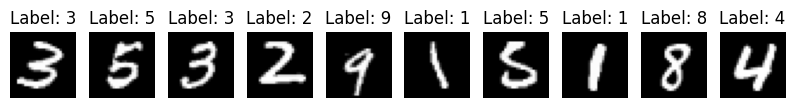

In [22]:
data.plot_random_samples(10)

In [23]:
SEED = 42

def get_network():
    net = Network()
    net.add(Dense(784, 10, ReLU(),    RandomNormal(0.01)))
    net.add(Dense(10,  10, Softmax(), RandomNormal(0.01)))
    return net

net = get_network()

@time_wrapper
def run_experiment(strategy, epochs=200, verbose_epoch=50):
    print_system_info()

    np.random.seed(SEED)
    net.reset_weights()
    np.random.seed()

    model = Model(net, MeanSquaredError(), SGD(learning_rate=0.05), strategy=strategy)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        X_val=X_test,
        y_val=y_test,
        verbose=True,
        verbose_epoch=verbose_epoch,
    )

    history.plot()
    model.evaluate(X_test, y_test)
    model.confusion_matrix(X_test, y_test)
    model.classification_report(X_test, y_test)

    return history

## Reporte estadístico para repeticiones

In [24]:
from dataclasses import dataclass, field

# ──────────────────────────────────────────────
# Resultado de una repetición
# ──────────────────────────────────────────────

@dataclass
class TrialResult:
    seed:        int
    train_loss:  float
    train_acc:   float
    val_loss:    float
    val_acc:     float


# ──────────────────────────────────────────────
# Resultado agregado del estudio
# ──────────────────────────────────────────────

@dataclass
class StudyResult:
    strategy_name: str
    trials:        list[TrialResult] = field(default_factory=list)

    # ── Estadísticas ──────────────────────────

    def _stats(self, values: list[float]) -> dict:
        a = np.array(values)
        return {
            "mean":   float(np.mean(a)),
            "std":    float(np.std(a)),
            "min":    float(np.min(a)),
            "max":    float(np.max(a)),
            "median": float(np.median(a)),
        }

    @property
    def train_acc_stats(self): return self._stats([t.train_acc  for t in self.trials])
    @property
    def val_acc_stats(self):   return self._stats([t.val_acc    for t in self.trials])
    @property
    def train_loss_stats(self):return self._stats([t.train_loss for t in self.trials])
    @property
    def val_loss_stats(self):  return self._stats([t.val_loss   for t in self.trials])

    # ── Print ─────────────────────────────────

    def _print_stats(self, label: str, stats: dict) -> None:
        print(f"\n--- {self.strategy_name} | {label} ---")
        print(f"  Media:          {stats['mean']:.4f}")
        print(f"  Desv. Estándar: {stats['std']:.4f}")
        print(f"  Mínimo:         {stats['min']:.4f}")
        print(f"  Máximo:         {stats['max']:.4f}")
        print(f"  Mediana:        {stats['median']:.4f}")

    def report(self) -> None:
        self._print_stats("Accuracy  TEST",  self.val_acc_stats)
        self._print_stats("Accuracy  TRAIN", self.train_acc_stats)
        self._print_stats("Loss      TEST",  self.val_loss_stats)
        self._print_stats("Loss      TRAIN", self.train_loss_stats)


# ──────────────────────────────────────────────
# Función principal
# ──────────────────────────────────────────────
@time_wrapper
def run_study(
    strategy_factory,       # callable que devuelve una estrategia nueva: lambda: BatchAvgStrategy(6000)
    network_factory,        # callable que devuelve una red nueva:         get_network
    cost,
    optimizer_factory,      # callable que devuelve un optimizer nuevo:    lambda: SGD(0.05)
    X_train, y_train,
    X_val,   y_val,
    repetitions: int = 30,
    epochs:      int = 200,
    seeds:       list[int] | int = None,
    verbose:     bool = True,
) -> StudyResult:
    """
    Repite el entrenamiento `repetitions` veces con seeds distintas.
    Cada repetición usa una instancia nueva de red, optimizer y estrategia.
    No modifica ninguna clase existente.

    Parámetros:
        strategy_factory  : lambda sin args → TrainingStrategy
        network_factory   : lambda sin args → Network
        optimizer_factory : lambda sin args → Optimizer
        seeds             : lista de ints; si None se generan automáticamente; si int se generan automáticamente reproducibilidad

    Retorna:
        StudyResult con estadísticas agregadas
    """
    if seeds is None or isinstance(seeds, int):
        rng   = np.random.default_rng(seeds)
        seeds = rng.integers(0, 100_000, size=repetitions).tolist()

    strategy_name = strategy_factory().__class__.__name__
    result        = StudyResult(strategy_name=strategy_name)

    for i, seed in enumerate(seeds):
        if verbose:
            print(f"[{strategy_name}] rep {i+1:>3}/{repetitions}  seed={seed}", end="\r")

        # ── Inicialización reproducible ──
        np.random.seed(seed)
        net = network_factory()
        np.random.seed()         # liberar seed para training aleatorio

        strategy  = strategy_factory()
        optimizer = optimizer_factory()
        model     = Model(net, cost, optimizer, strategy=strategy)

        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            X_val=X_val,
            y_val=y_val,
            verbose=False,       # silenciar epochs individuales
        )

        # ── Métricas finales de la repetición ──
        train_loss = history.train_loss[-1]
        train_acc  = history.train_accuracy[-1]
        val_loss   = history.val_loss[-1]
        val_acc    = history.val_accuracy[-1]

        result.trials.append(TrialResult(
            seed       = seed,
            train_loss = train_loss,
            train_acc  = train_acc,
            val_loss   = val_loss,
            val_acc    = val_acc,
        ))

    if verbose:
        print()  # salto de línea tras el \r

    return result

# Train

Epoch    1/200 [░░░░░░░░░░░░░░░░░░░░] loss=0.9000  acc=0.1144  ||g||=0.0636  |  val_loss=0.9000  val_acc=0.1401
Epoch   50/200 [█████░░░░░░░░░░░░░░░] loss=0.8918  acc=0.2513  ||g||=0.3542  |  val_loss=0.8910  val_acc=0.2526
Epoch  100/200 [██████████░░░░░░░░░░] loss=0.7525  acc=0.5079  ||g||=0.8577  |  val_loss=0.7464  val_acc=0.5090
Epoch  150/200 [███████████████░░░░░] loss=0.4520  acc=0.7457  ||g||=0.6015  |  val_loss=0.4415  val_acc=0.7567
Epoch  200/200 [████████████████████] loss=0.3232  acc=0.8075  ||g||=0.3612  |  val_loss=0.3147  val_acc=0.8170


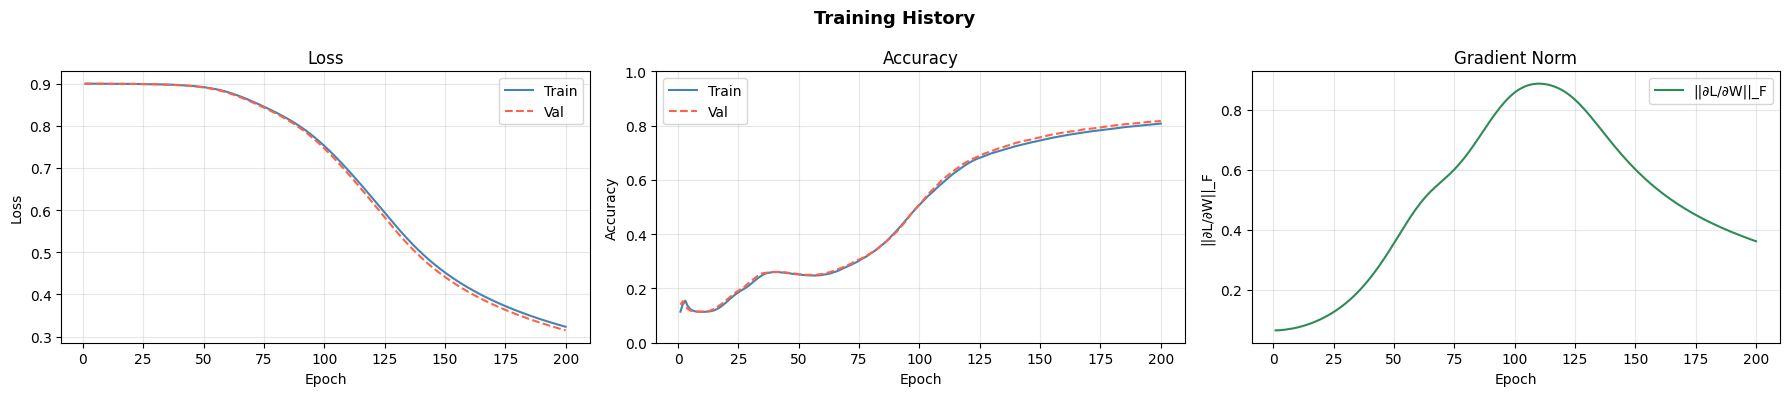

Loss: 0.3147  |  Accuracy: 0.8170 (81.70%)


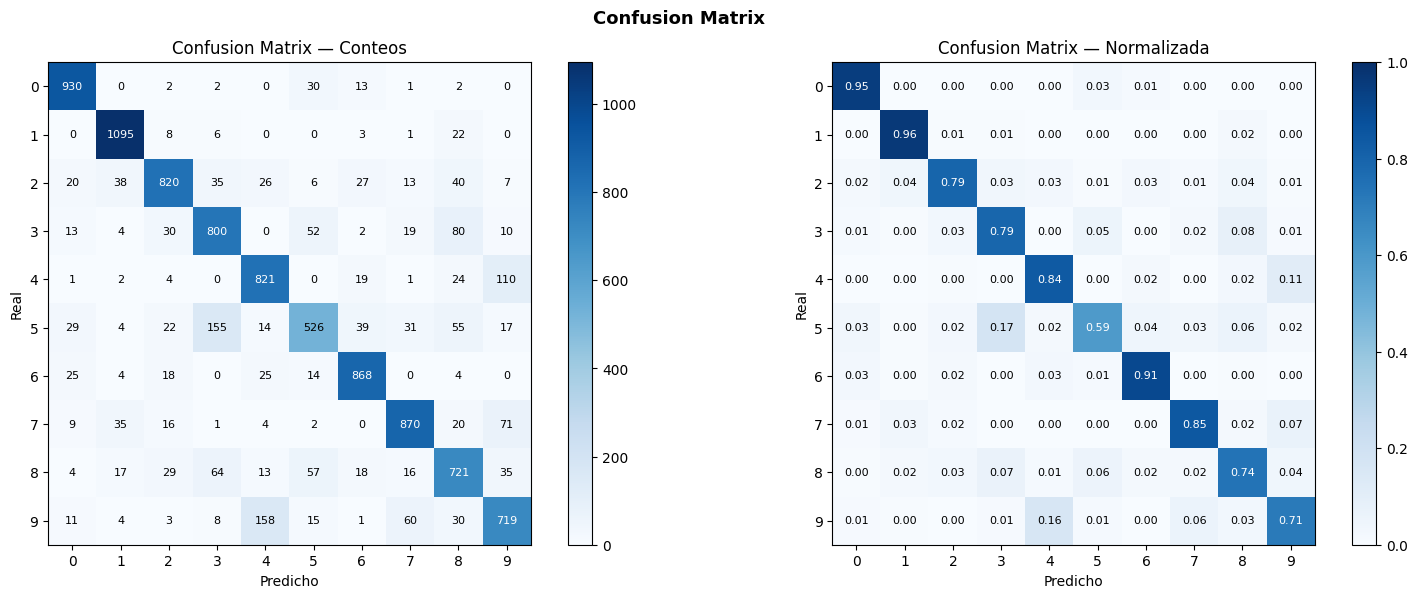


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8925       0.9490       0.9199      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8613       0.7946       0.8266      1032  
   3        0.7470       0.7921       0.7689      1010  
   4        0.7738       0.8360       0.8037      982   
   5        0.7493       0.5897       0.6600      892   
   6        0.8768       0.9061       0.8912      958   
   7        0.8597       0.8463       0.8529      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7126       0.7270      1009  
────────────────────────────────────────────────────
  avg       0.8135       0.8131       0.8118   
────────────────────────────────────────────────────



In [17]:
# Modo 1 — Batch GD completo
h_batch = run_experiment(FullBatchStrategy())

=== SYSTEM INFO ===
OS: Linux 6.6.113+
Machine: x86_64
CPU: Intel(R) Xeon(R) CPU @ 2.00GHz
Architecture: X86_64
Physical cores: 1
Logical threads: 2
RAM (GB): 12.67
Cuda available: True
cpu_count: 2
CUDA available: True
GPU Name: Tesla T4
VRAM Total (GB): 14.56
VRAM Allocated (GB): 0.00
VRAM Reserved (GB): 0.00
________________________________________
Epoch    1/200 [░░░░░░░░░░░░░░░░░░░░] loss=0.9000  acc=0.1145  ||g||=0.0685  |  val_loss=0.9000  val_acc=0.1401
Epoch   50/200 [█████░░░░░░░░░░░░░░░] loss=0.8918  acc=0.2513  ||g||=0.3556  |  val_loss=0.8910  val_acc=0.2526
Epoch  100/200 [██████████░░░░░░░░░░] loss=0.7525  acc=0.5079  ||g||=0.8616  |  val_loss=0.7464  val_acc=0.5090
Epoch  150/200 [███████████████░░░░░] loss=0.4520  acc=0.7457  ||g||=0.6183  |  val_loss=0.4415  val_acc=0.7567
Epoch  200/200 [████████████████████] loss=0.3232  acc=0.8075  ||g||=0.3934  |  val_loss=0.3147  val_acc=0.8170


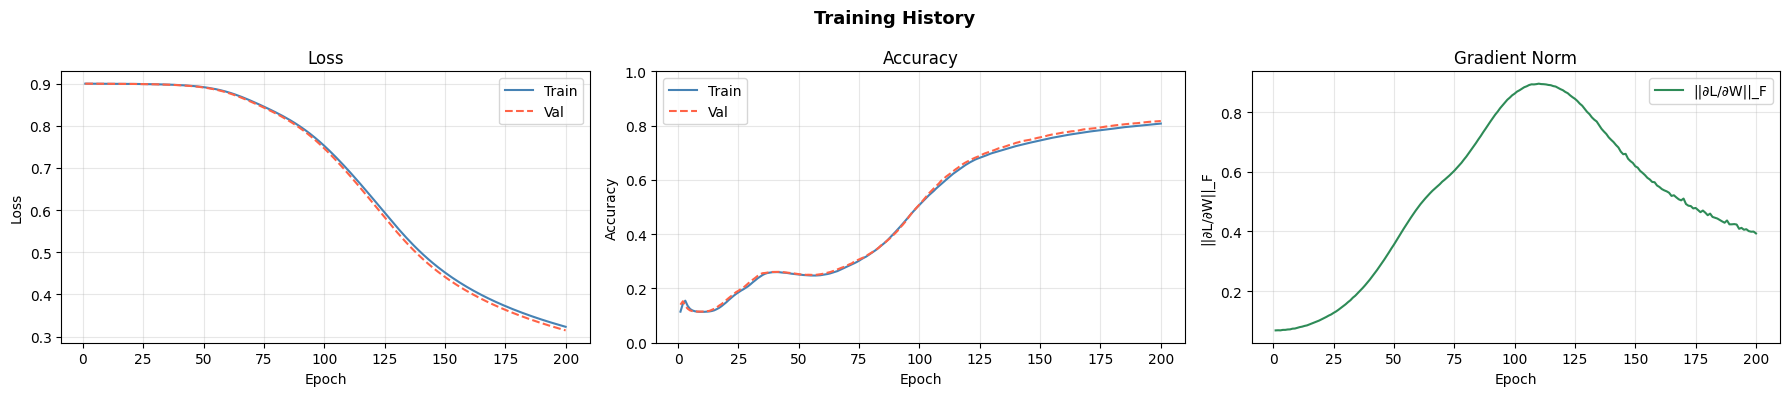

Loss: 0.3147  |  Accuracy: 0.8170 (81.70%)


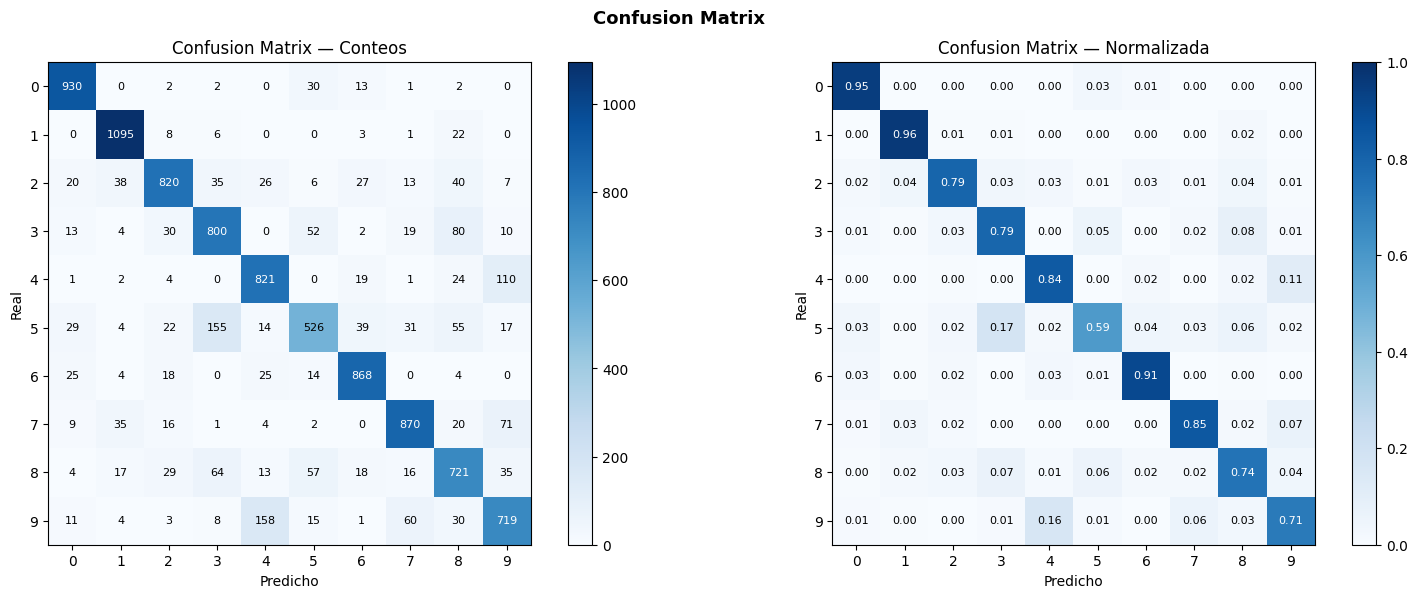


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8925       0.9490       0.9199      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8613       0.7946       0.8266      1032  
   3        0.7470       0.7921       0.7689      1010  
   4        0.7738       0.8360       0.8037      982   
   5        0.7493       0.5897       0.6600      892   
   6        0.8768       0.9061       0.8912      958   
   7        0.8597       0.8463       0.8529      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7126       0.7270      1009  
────────────────────────────────────────────────────
  avg       0.8135       0.8131       0.8118   
────────────────────────────────────────────────────

run_experiment took 3m 32.20s


In [ ]:
# Modo 2 — Promedio de pesos por época
h_batch_avg = run_experiment(BatchAvgStrategy(batch_size=6000))

=== SYSTEM INFO ===
OS: Linux 6.6.113+
Machine: x86_64
CPU: Intel(R) Xeon(R) CPU @ 2.00GHz
Architecture: X86_64
Physical cores: 1
Logical threads: 2
RAM (GB): 12.67
Cuda available: True
cpu_count: 2
CUDA available: True
GPU Name: Tesla T4
VRAM Total (GB): 14.56
VRAM Allocated (GB): 0.00
VRAM Reserved (GB): 0.00
________________________________________


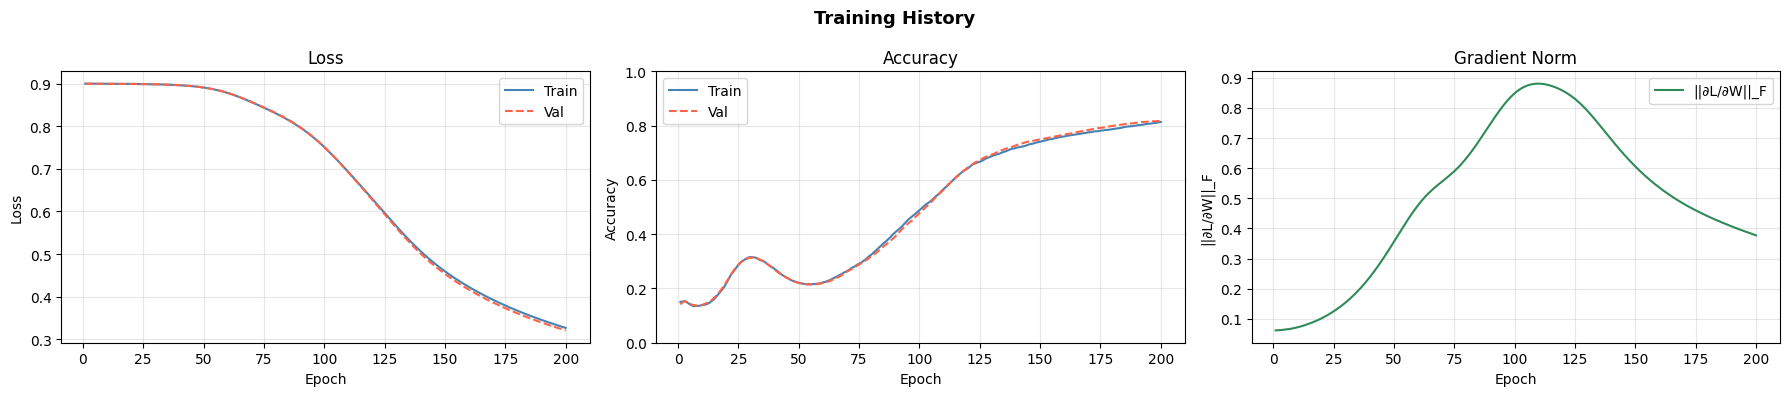

Loss: 0.3154  |  Accuracy: 0.8170 (81.70%)


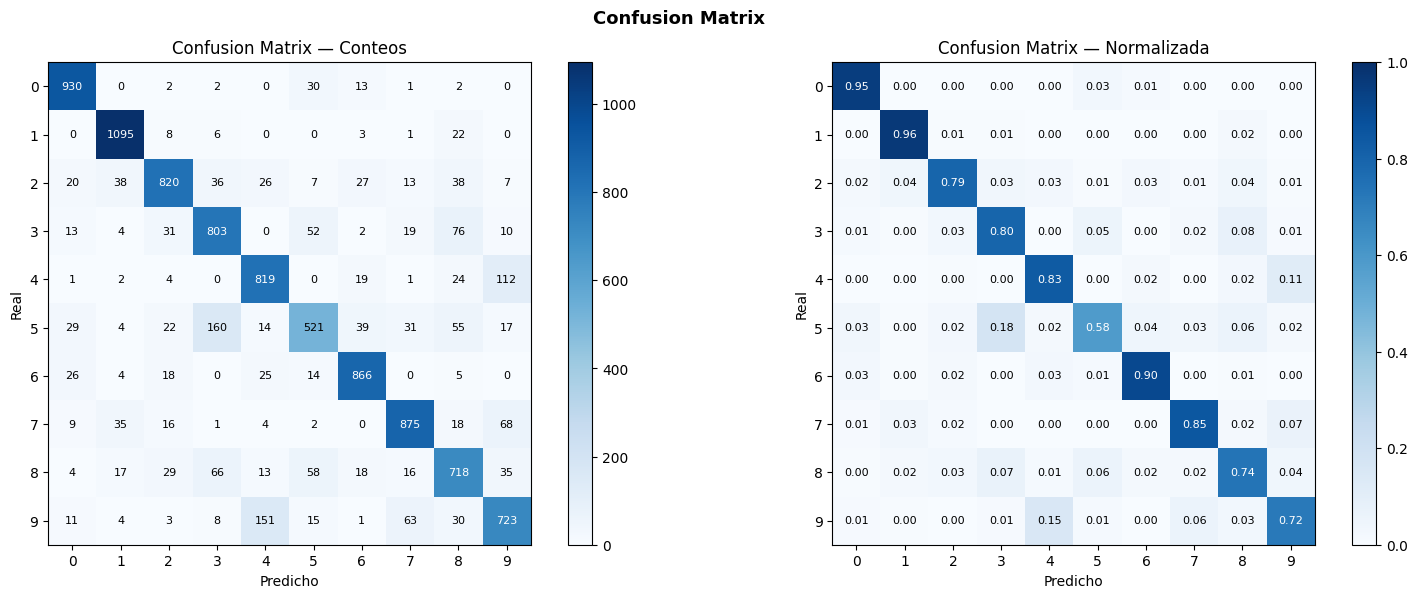


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8917       0.9490       0.9194      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8604       0.7946       0.8262      1032  
   3        0.7421       0.7950       0.7677      1010  
   4        0.7785       0.8340       0.8053      982   
   5        0.7454       0.5841       0.6549      892   
   6        0.8765       0.9040       0.8900      958   
   7        0.8578       0.8512       0.8545      1028  
   8        0.7267       0.7372       0.7319      974   
   9        0.7438       0.7166       0.7299      1009  
────────────────────────────────────────────────────
  avg       0.8133       0.8130       0.8117   
────────────────────────────────────────────────────

run_experiment took 1m 46.13s


In [ ]:
# Modo 3 — Final Avg (local_epochs se expone como epochs del History)
#           epochs=1 porque FinalAvgStrategy maneja su propio loop interno
h_final_avg = run_experiment(
    FinalAvgStrategy(n_workers=10, local_epochs=200),
    epochs=1,           # ← el loop externo corre 1 vez, el interno 200
    verbose_epoch=1,
)

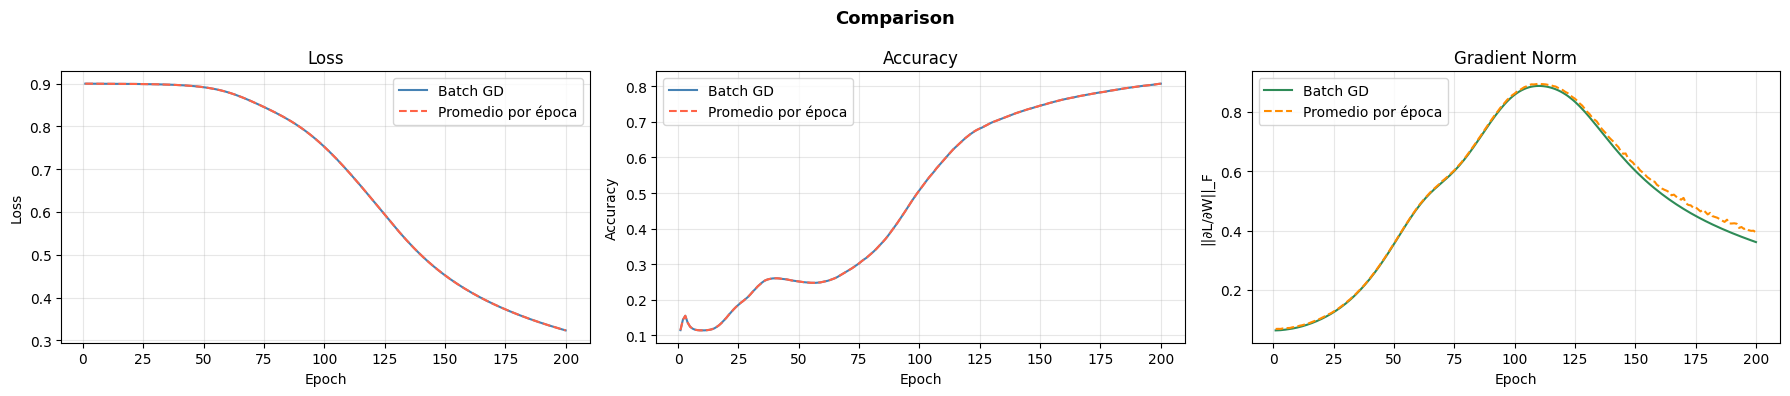

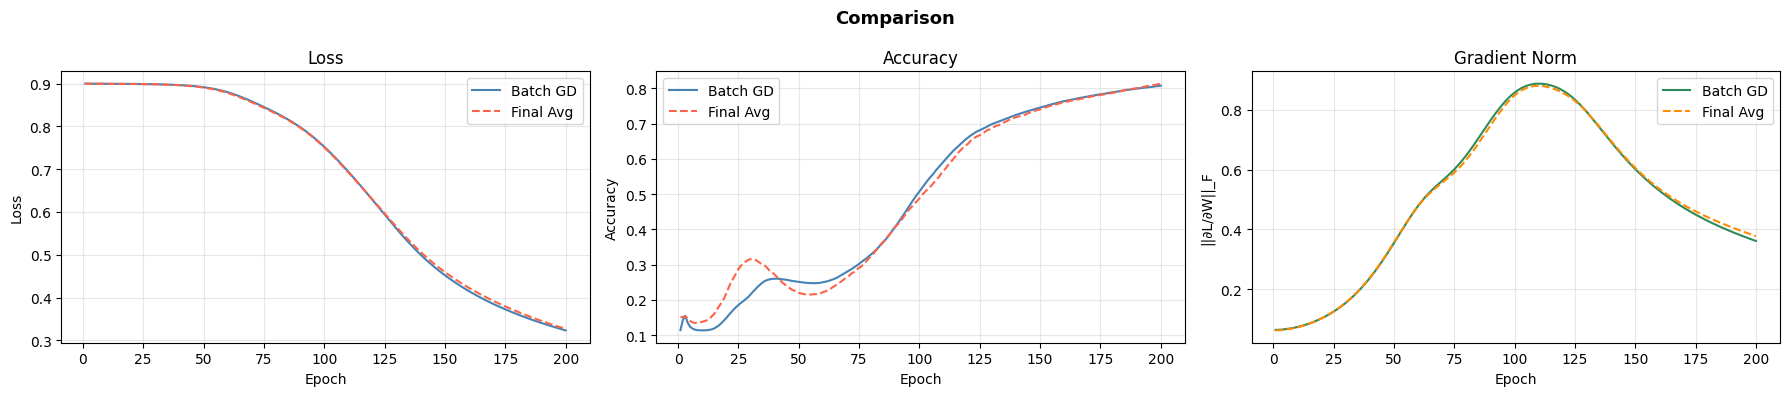

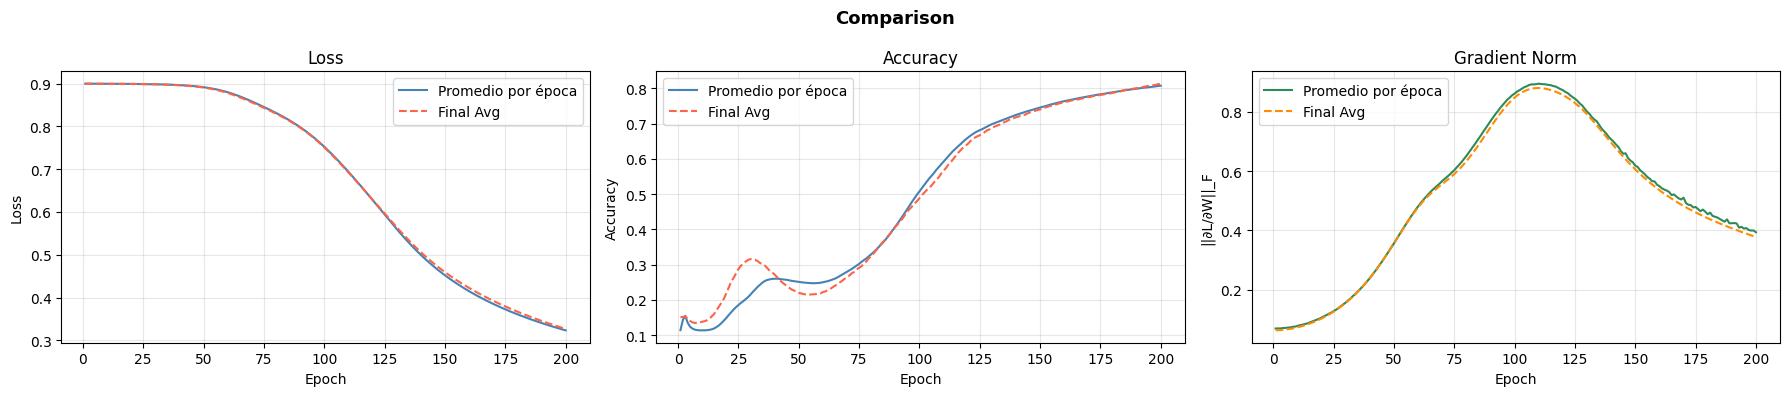

In [ ]:
h_batch.plot_comparison(h_batch_avg,  "Batch GD",  "Promedio por época")
h_batch.plot_comparison(h_final_avg,  "Batch GD",  "Final Avg")
h_batch_avg.plot_comparison(h_final_avg, "Promedio por época", "Final Avg")

# Prueba de repeticiones con estadísticas

In [ ]:
REPETITIONS = 20
EPOCHS      = 100
LR          = 0.1
BATCH_SIZE  = 6000
N_WORKERS   = 10
SEED_RNG    = 99

print_system_info()

# ── BatchAvgStrategy ──
study_batch_avg = run_study(
    strategy_factory  = lambda: BatchAvgStrategy(batch_size=BATCH_SIZE),
    network_factory   = get_network,
    cost              = MeanSquaredError(),
    optimizer_factory = lambda: SGD(learning_rate=LR),
    X_train=X_train, y_train=y_train,
    X_val=X_test,    y_val=y_test,
    repetitions = REPETITIONS,
    epochs      = EPOCHS,
    seeds       = SEED_RNG,
)

# ── FinalAvgStrategy ──
study_final_avg = run_study(
    strategy_factory  = lambda: FinalAvgStrategy(n_workers=N_WORKERS, local_epochs=EPOCHS),
    network_factory   = get_network,
    cost              = MeanSquaredError(),
    optimizer_factory = lambda: SGD(learning_rate=LR),
    X_train=X_train, y_train=y_train,
    X_val=X_test,    y_val=y_test,
    repetitions = REPETITIONS,
    epochs      = 1,              # FinalAvgStrategy maneja su propio loop
    seeds       = SEED_RNG,
)

# ── Reportes ──
study_batch_avg.report()
study_final_avg.report()

[BatchAvgStrategy] rep  20/20  seed=61005
run_study took 34m 11.34s
[FinalAvgStrategy] rep  20/20  seed=61005
run_study took 16m 52.90s
=== SYSTEM INFO ===
OS: Linux 6.6.113+
Machine: x86_64
CPU: Intel(R) Xeon(R) CPU @ 2.00GHz
Architecture: X86_64
Physical cores: 1
Logical threads: 2
RAM (GB): 12.67
Cuda available: True
cpu_count: 2
CUDA available: True
GPU Name: Tesla T4
VRAM Total (GB): 14.56
VRAM Allocated (GB): 0.00
VRAM Reserved (GB): 0.00
________________________________________

--- BatchAvgStrategy | Accuracy  TEST ---
  Media:          0.8117
  Desv. Estándar: 0.0150
  Mínimo:         0.7752
  Máximo:         0.8351
  Mediana:        0.8123

--- BatchAvgStrategy | Accuracy  TRAIN ---
  Media:          0.8037
  Desv. Estándar: 0.0169
  Mínimo:         0.7652
  Máximo:         0.8290
  Mediana:        0.8056

--- BatchAvgStrategy | Loss      TEST ---
  Media:          0.3177
  Desv. Estándar: 0.0231
  Mínimo:         0.2856
  Máximo:         0.3662
  Mediana:        0.3137

--- 

# Multi procesos

=== SYSTEM INFO ===
OS: Windows 10
Machine: AMD64
CPU: AMD Ryzen 5 4500U with Radeon Graphics
Architecture: X86_64
Physical cores: 6
Logical threads: 6
RAM (GB): 7.42
Cuda available: False
cpu_count: 6
CUDA available: False
________________________________________
Epoch    1/200 [░░░░░░░░░░░░░░░░░░░░] loss=0.9000  acc=0.1144  ||g||=0.0691  |  val_loss=0.9000  val_acc=0.1401
Epoch   50/200 [█████░░░░░░░░░░░░░░░] loss=0.8918  acc=0.2513  ||g||=0.3563  |  val_loss=0.8910  val_acc=0.2526
Epoch  100/200 [██████████░░░░░░░░░░] loss=0.7525  acc=0.5079  ||g||=0.8627  |  val_loss=0.7464  val_acc=0.5090
Epoch  150/200 [███████████████░░░░░] loss=0.4520  acc=0.7457  ||g||=0.6178  |  val_loss=0.4415  val_acc=0.7567
Epoch  200/200 [████████████████████] loss=0.3232  acc=0.8075  ||g||=0.3951  |  val_loss=0.3147  val_acc=0.8170


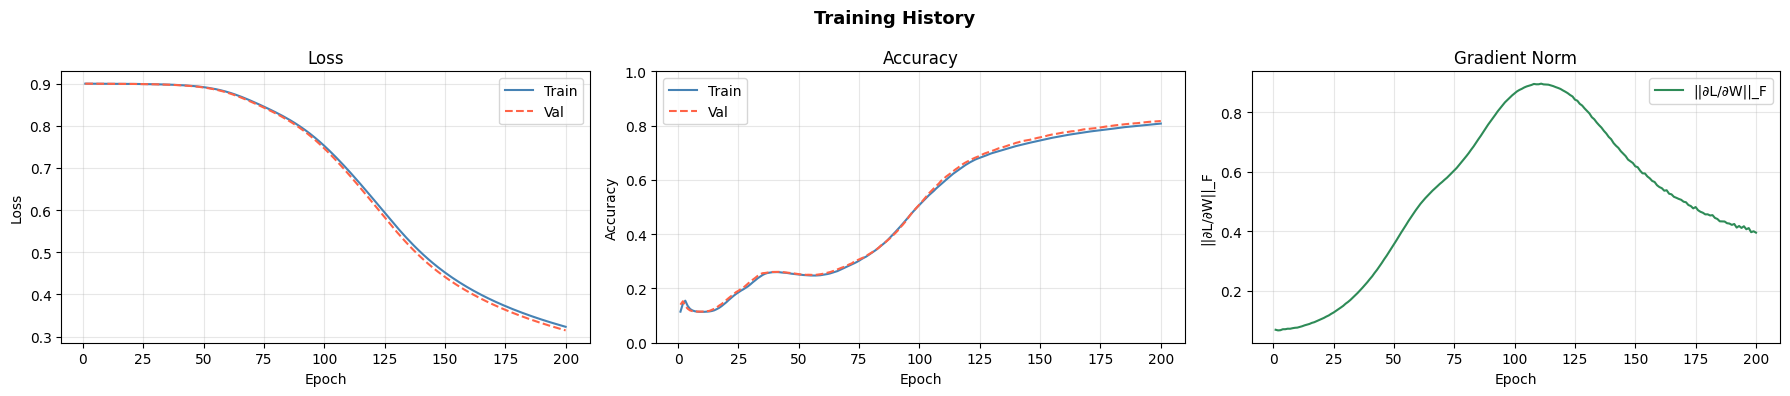

Loss: 0.3147  |  Accuracy: 0.8170 (81.70%)


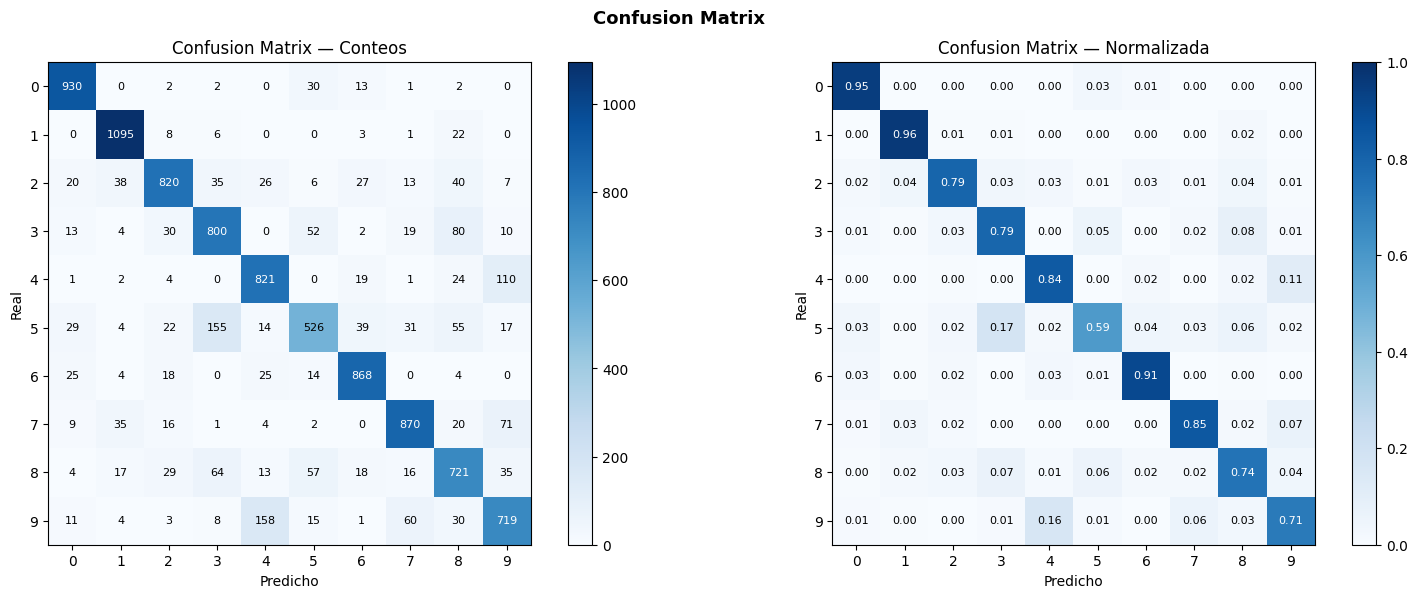


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8925       0.9490       0.9199      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8613       0.7946       0.8266      1032  
   3        0.7470       0.7921       0.7689      1010  
   4        0.7738       0.8360       0.8037      982   
   5        0.7493       0.5897       0.6600      892   
   6        0.8768       0.9061       0.8912      958   
   7        0.8597       0.8463       0.8529      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7126       0.7270      1009  
────────────────────────────────────────────────────
  avg       0.8135       0.8131       0.8118   
────────────────────────────────────────────────────

run_experiment took 3m 49.90s


In [22]:
history_batch_normal = run_experiment(BatchAvgStrategy(batch_size=6000))

In [30]:
def build_model():
    return Model(
        get_network(),
        MeanSquaredError(),
        SGD(learning_rate=0.05),
        strategy=None
    )

=== SYSTEM INFO ===
OS: Windows 10
Machine: AMD64
CPU: AMD Ryzen 5 4500U with Radeon Graphics
Architecture: X86_64
Physical cores: 6
Logical threads: 6
RAM (GB): 7.42
Cuda available: False
cpu_count: 6
CUDA available: False
________________________________________
Epoch    1/200 [░░░░░░░░░░░░░░░░░░░░] loss=0.9000  acc=0.1144  ||g||=0.0667  |  val_loss=0.9000  val_acc=0.1401
Epoch   50/200 [█████░░░░░░░░░░░░░░░] loss=0.8918  acc=0.2513  ||g||=0.3560  |  val_loss=0.8910  val_acc=0.2526
Epoch  100/200 [██████████░░░░░░░░░░] loss=0.7525  acc=0.5079  ||g||=0.8650  |  val_loss=0.7464  val_acc=0.5090
Epoch  150/200 [███████████████░░░░░] loss=0.4520  acc=0.7457  ||g||=0.6267  |  val_loss=0.4415  val_acc=0.7567
Epoch  200/200 [████████████████████] loss=0.3232  acc=0.8075  ||g||=0.4105  |  val_loss=0.3147  val_acc=0.8170


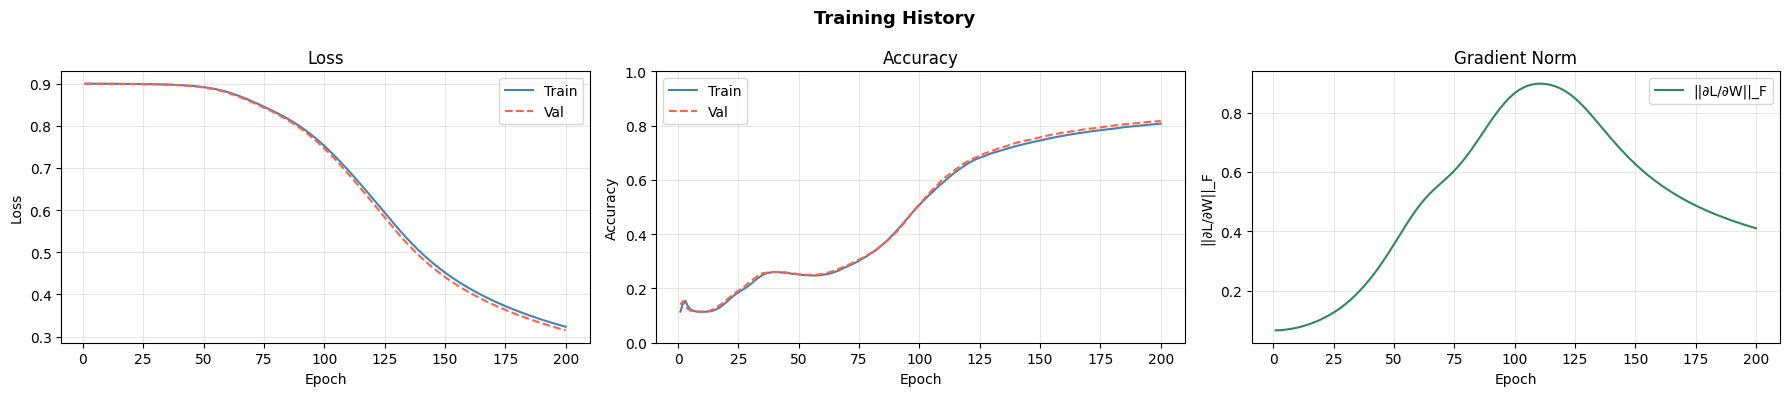

Loss: 0.3147  |  Accuracy: 0.8170 (81.70%)


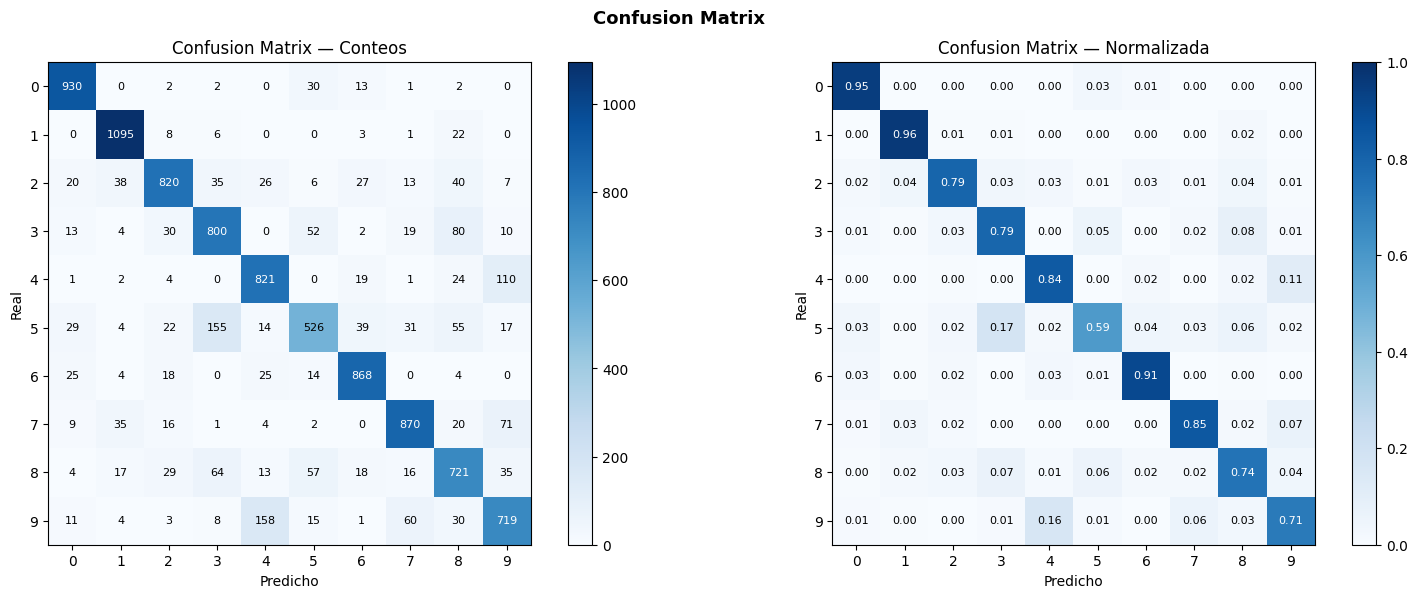


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8925       0.9490       0.9199      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8613       0.7946       0.8266      1032  
   3        0.7470       0.7921       0.7689      1010  
   4        0.7738       0.8360       0.8037      982   
   5        0.7493       0.5897       0.6600      892   
   6        0.8768       0.9061       0.8912      958   
   7        0.8597       0.8463       0.8529      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7126       0.7270      1009  
────────────────────────────────────────────────────
  avg       0.8135       0.8131       0.8118   
────────────────────────────────────────────────────

run_experiment took 2m 53.11s


In [31]:
strategy = ParallelBatchAvgStrategy(6000, model_fn=build_model)
history_batch_parallel = run_experiment(strategy, epochs=200, verbose_epoch=50)

In [ ]:
REPETITIONS = 20
EPOCHS      = 100
LR          = 0.1
BATCH_SIZE  = 6000
N_WORKERS   = 10

print_system_info()

# ── BatchAvgStrategy ──
study_parallel_batch_avg = run_study(
    strategy_factory  = lambda: ParallelBatchAvgStrategy(BATCH_SIZE, model_fn=build_model),
    network_factory   = get_network,
    cost              = MeanSquaredError(),
    optimizer_factory = lambda: SGD(learning_rate=LR),
    X_train=X_train, y_train=y_train,
    X_val=X_test,    y_val=y_test,
    repetitions = REPETITIONS,
    epochs      = EPOCHS,
    seeds       = 99,          # ← mismas seeds que los anteriores reportes sin ser paralelos
)

study_parallel_batch_avg.report()

[ParallelBatchAvgStrategy] rep  20/20  seed=61005
run_study took 29m 11.10s

--- ParallelBatchAvgStrategy | Accuracy  TEST ---
  Media:          0.5478
  Desv. Estándar: 0.0635
  Mínimo:         0.4205
  Máximo:         0.6429
  Mediana:        0.5650

--- ParallelBatchAvgStrategy | Accuracy  TRAIN ---
  Media:          0.5354
  Desv. Estándar: 0.0628
  Mínimo:         0.4094
  Máximo:         0.6270
  Mediana:        0.5497

--- ParallelBatchAvgStrategy | Loss      TEST ---
  Media:          0.7112
  Desv. Estándar: 0.0412
  Mínimo:         0.6540
  Máximo:         0.7837
  Mediana:        0.6945

--- ParallelBatchAvgStrategy | Loss      TRAIN ---
  Media:          0.7206
  Desv. Estándar: 0.0393
  Mínimo:         0.6658
  Máximo:         0.7924
  Mediana:        0.7051
